## Cross-Fitted Outlet Prediction Models

We train **two separate outlet-prediction models** on disjoint halves of the training data to enable **cross-fitting**. Both models share the same multimodal architecture and are trained to predict the news outlet from image content and associated metadata. We then use their out-of-sample predictions to construct a dispersion-based measure of visual disagreement across outlets, which serves as the core input to our **Overall Visual Polarization (OVP)** measure. Cross-fitting ensures that OVP is computed from independent predictions, mitigating overfitting and mechanical correlation between model estimation and polarization measurement.

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
import gensim
from gensim import corpora
from torchvision import models, transforms
from PIL import Image
import requests
from io import BytesIO
import torch_optimizer as optim
import numpy as np
import ast
from sklearn.utils.class_weight import compute_class_weight
from facenet_pytorch import MTCNN, InceptionResnetV1
import torch.optim as optim
import random

seed = 422
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

random_seed = 422

mtcnn = MTCNN(keep_all=False, device=torch.device('cpu'), thresholds=[0.4, 0.5, 0.6], min_face_size=15, factor=0.6)

df = pd.read_csv('data/cleaned_complete_data_Face_Verification_Info_Raady2.csv')
df['dataset_type'] = 'train'
df['prediction'] = None
df['stratify_col'] = df['News Center'] + '_' + df['Top1_Person']
group_counts = df['stratify_col'].value_counts()
sufficient_groups = group_counts[group_counts >= 2].index
df = df[df['stratify_col'].isin(sufficient_groups)]

train_df, val_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df['stratify_col'],
    random_state=random_seed
)

train_df['dataset_type'] = 'train'
val_df['dataset_type'] = 'val'

train1_df, train2_df = train_test_split(
    train_df,
    test_size=0.5,
    stratify=train_df['stratify_col'],
    random_state=random_seed
)

train1_df = train1_df.copy()
train2_df = train2_df.copy()
train1_df['dataset_type'] = 'train1'
train2_df['dataset_type'] = 'train2'

df = pd.concat([train_df, val_df], ignore_index=True)
df.drop(columns=['stratify_col'], inplace=True)

print("Training set details:")
print(f"Number of 'News Center' categories: {train_df['News Center'].nunique()}")
print(f"Number of 'Top1_Person' categories: {train_df['Top1_Person'].nunique()}")
print(f"Number of 'Real Person Side' categories: {train_df['Real Person Side'].nunique()}")
print(f"Number of 'Date' categories: {train_df['Date'].nunique()}")

print("\nValidation set details:")
print(f"Number of 'News Center' categories: {val_df['News Center'].nunique()}")
print(f"Number of 'Top1_Person' categories: {val_df['Top1_Person'].nunique()}")
print(f"Number of 'Real Person Side' categories: {val_df['Real Person Side'].nunique()}")
print(f"Number of 'Date' categories: {val_df['Date'].nunique()}")

df.to_pickle('cleaned_complete_data_Face_Verification_Info_Raady_MLModel_Date.pkl')

num_person_categories = df['Top1_Person'].nunique()
num_party_categories = df['Real Person Side'].nunique()
num_topics = len([col for col in df.columns if col.startswith('topic_')])
num_classes = df['News Center'].nunique()

df["YearMonth"] = pd.to_datetime(df["Date_Pub"], errors="coerce").dt.to_period("M").astype(str)
train_df["YearMonth"] = pd.to_datetime(train_df["Date_Pub"], errors="coerce").dt.to_period("M").astype(str)
val_df["YearMonth"] = pd.to_datetime(val_df["Date_Pub"], errors="coerce").dt.to_period("M").astype(str)
train1_df["YearMonth"] = pd.to_datetime(train1_df["Date_Pub"], errors="coerce").dt.to_period("M").astype(str)
train2_df["YearMonth"] = pd.to_datetime(train2_df["Date_Pub"], errors="coerce").dt.to_period("M").astype(str)

num_date_categories = df['YearMonth'].nunique()
print(num_date_categories)

class NewsDataset(Dataset):
    def __init__(self, dataframe, image_dir='data/images_Polarization', transform=None, face_transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
        self.face_transform = face_transform
        self.person_encoder = LabelEncoder()
        self.outlet_encoder = LabelEncoder()
        self.party_encoder = LabelEncoder()
        self.date_encoder = LabelEncoder()
        self.person_encoder.fit(dataframe['Top1_Person'])
        self.outlet_encoder.fit(dataframe['News Center'])
        self.party_encoder.fit(dataframe['Real Person Side'])
        self.date_encoder.fit(dataframe['YearMonth'])
        self.person_encoded = self.person_encoder.transform(dataframe['Top1_Person'])
        self.outlet_encoded = self.outlet_encoder.transform(dataframe['News Center'])
        self.party_encoded = self.party_encoder.transform(dataframe['Real Person Side'])
        self.topic_columns = [col for col in dataframe.columns if col.startswith('topic_')]
        self.dates = self.date_encoder.transform(dataframe['YearMonth'])

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_id = self.dataframe.iloc[idx]['ID']
        img_path = os.path.join(self.image_dir, f"{img_id}.jpg")
        img = Image.open(img_path).convert('RGB')
        face_img = mtcnn(img)
        if face_img is None:
            face_img = transforms.Resize((224, 224))(img)
            face_img = transforms.ToTensor()(face_img)
        else:
            face_img = transforms.Resize((224, 224))(face_img)
        if self.transform:
            img = self.transform(img)
        if self.face_transform:
            face_img = self.face_transform(face_img)
        label = self.outlet_encoded[idx]
        person = self.person_encoded[idx]
        party = self.party_encoded[idx]
        date = torch.tensor(self.dates[idx], dtype=torch.long)
        topic_distribution = self.dataframe.iloc[idx][self.topic_columns].values
        topic_distribution = np.array(topic_distribution, dtype=np.float32)
        topic_distribution = torch.tensor(topic_distribution)
        return img, face_img, torch.tensor(label, dtype=torch.long), torch.tensor(person, dtype=torch.long), torch.tensor(party, dtype=torch.long), topic_distribution, date

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

face_transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
])

train1_dataset = NewsDataset(train1_df, transform=transform)
train2_dataset = NewsDataset(train2_df, transform=transform)
val_dataset = NewsDataset(val_df, transform=transform)

num_workers = 50
train1_loader = DataLoader(train1_dataset, batch_size=64, shuffle=True, num_workers=num_workers)
train2_loader = DataLoader(train2_dataset, batch_size=64, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=num_workers)

class MultiHeadAttention(nn.Module):
    def __init__(self, embed_size, heads):
        super(MultiHeadAttention, self).__init__()
        self.embed_size = embed_size
        self.heads = heads
        self.head_dim = embed_size // heads
        assert self.head_dim * heads == embed_size
        self.values = nn.Linear(embed_size, embed_size, bias=False)
        self.keys = nn.Linear(embed_size, embed_size, bias=False)
        self.queries = nn.Linear(embed_size, embed_size, bias=False)
        self.fc_out = nn.Linear(embed_size, embed_size)

    def forward(self, values, keys, query):
        N = query.shape[0]
        value_len, key_len, query_len = values.shape[1], keys.shape[1], query.shape[1]
        values = self.values(values)
        keys = self.keys(keys)
        queries = self.queries(query)
        values = values.reshape(N, value_len, self.heads, self.head_dim)
        keys = keys.reshape(N, key_len, self.heads, self.head_dim)
        queries = queries.reshape(N, query_len, self.heads, self.head_dim)
        energy = torch.einsum("nqhd,nkhd->nhqk", [queries, keys])
        attention = torch.nn.functional.softmax(energy / (self.embed_size ** (1 / 2)), dim=3)
        out = torch.einsum("nhql,nlhd->nqhd", [attention, values]).reshape(N, query_len, self.heads * self.head_dim)
        out = self.fc_out(out)
        return out

class ImprovedMultiModalModel(nn.Module):
    def __init__(self, num_person_categories, num_party_categories, num_topics, num_classes,
                 num_date_categories, embedding_dim_person=8, embedding_dim_party=2,
                 embedding_dim_date=4, num_attention_heads=8, window_size=32):
        super(ImprovedMultiModalModel, self).__init__()
        self.face_vgg = InceptionResnetV1(pretrained='vggface2').eval()
        for param in list(self.face_vgg.parameters())[:-5]:
            param.requires_grad = False
        self.fc_vgg_1 = nn.Linear(512, 256)
        self.bn_vgg = nn.BatchNorm1d(256)
        self.dropout_vgg = nn.Dropout(0.3)
        self.person_embedding = nn.Embedding(num_person_categories, embedding_dim_person)
        self.party_embedding = nn.Embedding(num_party_categories, embedding_dim_party)
        self.date_embedding = nn.Embedding(num_date_categories, embedding_dim_date)
        self.fc_structured_proj = nn.Linear(embedding_dim_person + embedding_dim_party + num_topics + embedding_dim_date, 64)
        self.structured_attention = MultiHeadAttention(embed_size=64, heads=num_attention_heads)
        self.bn_structured = nn.BatchNorm1d(64)
        self.dropout_structured = nn.Dropout(0.4)
        self.fc_person_party_proj = nn.Linear(embedding_dim_person + embedding_dim_party, window_size)
        self.chunked_attention = MultiHeadAttention(embed_size=window_size, heads=num_attention_heads)
        resnet_pretrained = models.resnet101(pretrained=True)
        for param in list(resnet_pretrained.parameters())[:-10]:
            param.requires_grad = False
        self.features_resnet = nn.Sequential(*list(resnet_pretrained.children())[:-1])
        self.fc_resnet = nn.Linear(resnet_pretrained.fc.in_features, 512)
        self.bn_resnet = nn.BatchNorm1d(512)
        self.dropout_resnet = nn.Dropout(0.6)
        self.fc_out = nn.Linear(256 + 64 + 512, num_classes)
        self.dropout_out = nn.Dropout(0.5)

    def forward(self, resnet_img, face_img, person, party, topic_distribution, date):
        vgg_features = self.face_vgg(face_img)
        vgg_features = F.relu(self.bn_vgg(self.fc_vgg_1(vgg_features)))
        vgg_features = self.dropout_vgg(vgg_features)
        person_embedded = self.person_embedding(person)
        party_embedded = self.party_embedding(party)
        date_embedded = self.date_embedding(date)
        structured_data = torch.cat((person_embedded, party_embedded, topic_distribution, date_embedded), dim=1)
        structured_data_proj = F.relu(self.fc_structured_proj(structured_data))
        structured_data = self.structured_attention(structured_data_proj.unsqueeze(1), structured_data_proj.unsqueeze(1), structured_data_proj.unsqueeze(1)).squeeze(1)
        structured_data = F.relu(self.bn_structured(structured_data))
        structured_data = self.dropout_structured(structured_data)
        person_party_data = torch.cat((person_embedded, party_embedded), dim=1)
        person_party_proj = self.fc_person_party_proj(person_party_data).unsqueeze(1)
        vgg_chunks = vgg_features.view(vgg_features.size(0), 8, -1)
        attended_chunks = []
        for i in range(8):
            vgg_chunk = vgg_chunks[:, i, :].unsqueeze(1)
            attention_out = self.chunked_attention(person_party_proj, vgg_chunk, vgg_chunk).squeeze(1)
            attended_chunks.append(attention_out)
        attended_vgg_features = torch.cat(attended_chunks, dim=1)
        resnet_features = self.features_resnet(resnet_img)
        resnet_features = torch.flatten(resnet_features, 1)
        resnet_features = F.relu(self.bn_resnet(self.fc_resnet(resnet_features)))
        resnet_features = self.dropout_resnet(resnet_features)
        combined_features = torch.cat((attended_vgg_features, structured_data, resnet_features), dim=1)
        combined_features = self.dropout_out(combined_features)
        out = self.fc_out(combined_features)
        return out

embedding_dim_person = 8
embedding_dim_party = 2
embedding_dim_date = 4
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model1 = ImprovedMultiModalModel(
    num_person_categories=num_person_categories,
    num_party_categories=num_party_categories,
    num_topics=num_topics,
    num_classes=num_classes,
    num_date_categories=num_date_categories,
    embedding_dim_person=embedding_dim_person,
    embedding_dim_party=embedding_dim_party,
    embedding_dim_date=embedding_dim_date,
    num_attention_heads=8
).to(device)

model2 = ImprovedMultiModalModel(
    num_person_categories=num_person_categories,
    num_party_categories=num_party_categories,
    num_topics=num_topics,
    num_classes=num_classes,
    num_date_categories=num_date_categories,
    embedding_dim_person=embedding_dim_person,
    embedding_dim_party=embedding_dim_party,
    embedding_dim_date=embedding_dim_date,
    num_attention_heads=8
).to(device)

class_weights = compute_class_weight('balanced', classes=np.unique(df['News Center']), y=df['News Center'])
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

optimizer1 = torch.optim.AdamW(model1.parameters(), lr=0.0005, weight_decay=0.03)
optimizer2 = torch.optim.AdamW(model2.parameters(), lr=0.0005, weight_decay=0.03)

torch.nn.utils.clip_grad_norm_(model1.parameters(), max_norm=1.0)
torch.nn.utils.clip_grad_norm_(model2.parameters(), max_norm=1.0)

def train_two_models(model1, model2,
                     criterion,
                     optimizer1, optimizer2,
                     train1_loader, train2_loader,
                     val_loader,
                     num_epochs,
                     device,
                     save_path1='model_checkpoint_MultiClasses_With_Date_6_train1',
                     save_path2='model_checkpoint_MultiClasses_With_Date_6_train2'):

    epoch_train1_acc, epoch_val1_acc = [], []
    epoch_train1_losses, epoch_val1_losses = [], []

    epoch_train2_acc, epoch_val2_acc = [], []
    epoch_train2_losses, epoch_val2_losses = [], []

    for epoch in range(num_epochs):
        print(f"\n=========== Epoch {epoch+1}/{num_epochs} ===========")

        model1.train()
        running_train1_loss = 0.0
        running_train1_correct = 0
        running_train1_total = 0

        train1_progress_bar = tqdm(train1_loader,
                                   desc=f'Model1 Epoch {epoch+1}/{num_epochs} Training',
                                   unit='batch')
        for img, face_img, label, person, party, topic_distribution, date in train1_progress_bar:
            img = img.to(device)
            face_img = face_img.to(device)
            person = person.to(device)
            party = party.to(device)
            topic_distribution = topic_distribution.to(device)
            date = date.to(device)
            label = label.to(device)

            optimizer1.zero_grad()
            outputs = model1(img, face_img, person, party, topic_distribution, date)
            loss = criterion(outputs, label)
            loss.backward()
            optimizer1.step()

            running_train1_loss += loss.item() * label.size(0)
            _, preds = torch.max(outputs, 1)
            running_train1_correct += torch.sum(preds == label).item()
            running_train1_total += label.size(0)

        avg_train1_loss = running_train1_loss / running_train1_total
        avg_train1_acc = running_train1_correct / running_train1_total
        epoch_train1_losses.append(avg_train1_loss)
        epoch_train1_acc.append(avg_train1_acc)

        model1.eval()
        running_val1_loss = 0.0
        running_val1_correct = 0
        running_val1_total = 0

        val1_progress_bar = tqdm(val_loader,
                                 desc=f'Model1 Epoch {epoch+1}/{num_epochs} Validation',
                                 unit='batch')
        with torch.no_grad():
            for img, face_img, label, person, party, topic_distribution, date in val1_progress_bar:
                img = img.to(device)
                face_img = face_img.to(device)
                person = person.to(device)
                party = party.to(device)
                topic_distribution = topic_distribution.to(device)
                date = date.to(device)
                label = label.to(device)

                outputs = model1(img, face_img, person, party, topic_distribution, date)
                val_loss = criterion(outputs, label)
                running_val1_loss += val_loss.item() * label.size(0)
                _, preds = torch.max(outputs, 1)
                running_val1_correct += torch.sum(preds == label).item()
                running_val1_total += label.size(0)

        avg_val1_loss = running_val1_loss / running_val1_total
        avg_val1_acc = running_val1_correct / running_val1_total
        epoch_val1_losses.append(avg_val1_loss)
        epoch_val1_acc.append(avg_val1_acc)

        os.makedirs(save_path1, exist_ok=True)
        torch.save({
            'epoch': epoch,
            'model_state_dict': model1.state_dict(),
            'optimizer_state_dict': optimizer1.state_dict(),
            'train_loss': avg_train1_loss,
            'train_acc': avg_train1_acc,
            'val_loss': avg_val1_loss,
            'val_acc': avg_val1_acc
        }, os.path.join(save_path1, f'epoch_{epoch}.pth'))

        plt.figure(figsize=(14, 5))
        plt.suptitle(f'Model 1 – Epoch {epoch+1}')
        plt.subplot(1, 2, 1)
        plt.plot(range(1, epoch+2), epoch_train1_acc, 'bo-', label='Train Accuracy')
        plt.plot(range(1, epoch+2), epoch_val1_acc, 'ro-', label='Validation Accuracy')
        plt.title('Training and Validation Accuracy')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(range(1, epoch+2), epoch_train1_losses, 'bo-', label='Training Loss')
        plt.plot(range(1, epoch+2), epoch_val1_losses, 'ro-', label='Validation Loss')
        plt.title('Training and Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        model2.train()
        running_train2_loss = 0.0
        running_train2_correct = 0
        running_train2_total = 0

        train2_progress_bar = tqdm(train2_loader,
                                   desc=f'Model2 Epoch {epoch+1}/{num_epochs} Training',
                                   unit='batch')
        for img, face_img, label, person, party, topic_distribution, date in train2_progress_bar:
            img = img.to(device)
            face_img = face_img.to(device)
            person = person.to(device)
            party = party.to(device)
            topic_distribution = topic_distribution.to(device)
            date = date.to(device)
            label = label.to(device)

            optimizer2.zero_grad()
            outputs = model2(img, face_img, person, party, topic_distribution, date)
            loss = criterion(outputs, label)
            loss.backward()
            optimizer2.step()

            running_train2_loss += loss.item() * label.size(0)
            _, preds = torch.max(outputs, 1)
            running_train2_correct += torch.sum(preds == label).item()
            running_train2_total += label.size(0)

        avg_train2_loss = running_train2_loss / running_train2_total
        avg_train2_acc = running_train2_correct / running_train2_total
        epoch_train2_losses.append(avg_train2_loss)
        epoch_train2_acc.append(avg_train2_acc)

        model2.eval()
        running_val2_loss = 0.0
        running_val2_correct = 0
        running_val2_total = 0

        val2_progress_bar = tqdm(val_loader,
                                 desc=f'Model2 Epoch {epoch+1}/{num_epochs} Validation',
                                 unit='batch')
        with torch.no_grad():
            for img, face_img, label, person, party, topic_distribution, date in val2_progress_bar:
                img = img.to(device)
                face_img = face_img.to(device)
                person = person.to(device)
                party = party.to(device)
                topic_distribution = topic_distribution.to(device)
                date = date.to(device)
                label = label.to(device)

                outputs = model2(img, face_img, person, party, topic_distribution, date)
                val_loss = criterion(outputs, label)
                running_val2_loss += val_loss.item() * label.size(0)
                _, preds = torch.max(outputs, 1)
                running_val2_correct += torch.sum(preds == label).item()
                running_val2_total += label.size(0)

        avg_val2_loss = running_val2_loss / running_val2_total
        avg_val2_acc = running_val2_correct / running_val2_total
        epoch_val2_losses.append(avg_val2_loss)
        epoch_val2_acc.append(avg_val2_acc)

        os.makedirs(save_path2, exist_ok=True)
        torch.save({
            'epoch': epoch,
            'model_state_dict': model2.state_dict(),
            'optimizer_state_dict': optimizer2.state_dict(),
            'train_loss': avg_train2_loss,
            'train_acc': avg_train2_acc,
            'val_loss': avg_val2_loss,
            'val_acc': avg_val2_acc
        }, os.path.join(save_path2, f'epoch_{epoch}.pth'))

        plt.figure(figsize=(14, 5))
        plt.suptitle(f'Model 2 – Epoch {epoch+1}')
        plt.subplot(1, 2, 1)
        plt.plot(range(1, epoch+2), epoch_train2_acc, 'bo-', label='Train Accuracy')
        plt.plot(range(1, epoch+2), epoch_val2_acc, 'ro-', label='Validation Accuracy')
        plt.title('Training and Validation Accuracy')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(range(1, epoch+2), epoch_train2_losses, 'bo-', label='Training Loss')
        plt.plot(range(1, epoch+2), epoch_val2_losses, 'ro-', label='Validation Loss')
        plt.title('Training and Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

train_two_models(
    model1=model1,
    model2=model2,
    criterion=criterion,
    optimizer1=optimizer1,
    optimizer2=optimizer2,
    train1_loader=train1_loader,
    train2_loader=train2_loader,
    val_loader=val_loader,
    num_epochs=50,
    device=device,
    save_path1='model_checkpoint_train1',
    save_path2='model_checkpoint_train2'
)

## Counterfactual Image Prediction for Visual Polarization

We generate **counterfactual predictions** by applying the trained outlet-prediction model to synthetically modified images that differ only in a targeted visual attribute (e.g., the presence of a smile). For each validation article, we evaluate the model on multiple counterfactual image views with and without the attribute and obtain outlet probability vectors under both conditions. We then construct image-level counterfactual effects as log changes in relative outlet likelihoods, normalized to a neutral benchmark outlet, and aggregate these effects across views. These counterfactual predictions provide the fundamental inputs used to compute outlet-level visual slant and, through cross-fitted dispersion, **Overall Visual Polarization (OVP)**.

### Model 1 (Counterfactual Prediction)

In [ ]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image, UnidentifiedImageError
import requests
from io import BytesIO
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from tqdm import tqdm
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os
import matplotlib.pyplot as plt
import gensim
from gensim import corpora
from torchvision import models
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import numpy as np
from facenet_pytorch import InceptionResnetV1, MTCNN

torch.backends.cudnn.benchmark = True

class MultiHeadAttention(nn.Module):
    def __init__(self, embed_size, heads):
        super(MultiHeadAttention, self).__init__()
        self.embed_size = embed_size
        self.heads = heads
        self.head_dim = embed_size // heads
        assert self.head_dim * heads == embed_size
        self.values = nn.Linear(embed_size, embed_size, bias=False)
        self.keys = nn.Linear(embed_size, embed_size, bias=False)
        self.queries = nn.Linear(embed_size, embed_size, bias=False)
        self.fc_out = nn.Linear(embed_size, embed_size)

    def forward(self, values, keys, query):
        N = query.shape[0]
        value_len, key_len, query_len = values.shape[1], keys.shape[1], query.shape[1]
        values = self.values(values)
        keys = self.keys(keys)
        queries = self.queries(query)
        values = values.reshape(N, value_len, self.heads, self.head_dim)
        keys = keys.reshape(N, key_len, self.heads, self.head_dim)
        queries = queries.reshape(N, query_len, self.heads, self.head_dim)
        energy = torch.einsum("nqhd,nkhd->nhqk", [queries, keys])
        attention = torch.nn.functional.softmax(energy / (self.embed_size ** (1 / 2)), dim=3)
        out = torch.einsum("nhql,nlhd->nqhd", [attention, values]).reshape(
            N, query_len, self.heads * self.head_dim
        )
        out = self.fc_out(out)
        return out


class ImprovedMultiModalModel(nn.Module):
    def __init__(self, num_person_categories, num_party_categories, num_topics, num_classes,
                 num_date_categories, embedding_dim_person=8, embedding_dim_party=2,
                 embedding_dim_date=4, num_attention_heads=8, window_size=32):
        super(ImprovedMultiModalModel, self).__init__()
        self.face_vgg = InceptionResnetV1(pretrained='vggface2').eval()
        for param in list(self.face_vgg.parameters())[:-5]:
            param.requires_grad = False
        self.fc_vgg_1 = nn.Linear(512, 256)
        self.bn_vgg = nn.BatchNorm1d(256)
        self.dropout_vgg = nn.Dropout(0.3)
        self.person_embedding = nn.Embedding(num_person_categories, embedding_dim_person)
        self.party_embedding = nn.Embedding(num_party_categories, embedding_dim_party)
        self.date_embedding = nn.Embedding(num_date_categories, embedding_dim_date)
        self.fc_structured_proj = nn.Linear(embedding_dim_person + embedding_dim_party + num_topics + embedding_dim_date, 64)
        self.structured_attention = MultiHeadAttention(embed_size=64, heads=num_attention_heads)
        self.bn_structured = nn.BatchNorm1d(64)
        self.dropout_structured = nn.Dropout(0.4)
        self.fc_person_party_proj = nn.Linear(embedding_dim_person + embedding_dim_party, window_size)
        self.chunked_attention = MultiHeadAttention(embed_size=window_size, heads=num_attention_heads)
        resnet_pretrained = models.resnet101(pretrained=True)
        for param in list(resnet_pretrained.parameters())[:-10]:
            param.requires_grad = False
        self.features_resnet = nn.Sequential(*list(resnet_pretrained.children())[:-1])
        self.fc_resnet = nn.Linear(resnet_pretrained.fc.in_features, 512)
        self.bn_resnet = nn.BatchNorm1d(512)
        self.dropout_resnet = nn.Dropout(0.6)
        self.fc_out = nn.Linear(256 + 64 + 512, num_classes)
        self.dropout_out = nn.Dropout(0.5)

    def forward(self, resnet_img, face_img, person, party, topic_distribution, date):
        vgg_features = self.face_vgg(face_img)
        vgg_features = F.relu(self.bn_vgg(self.fc_vgg_1(vgg_features)))
        vgg_features = self.dropout_vgg(vgg_features)
        person_embedded = self.person_embedding(person)
        party_embedded = self.party_embedding(party)
        date_embedded = self.date_embedding(date)
        structured_data = torch.cat((person_embedded, party_embedded, topic_distribution, date_embedded), dim=1)
        structured_data_proj = F.relu(self.fc_structured_proj(structured_data))
        structured_data = self.structured_attention(
            structured_data_proj.unsqueeze(1),
            structured_data_proj.unsqueeze(1),
            structured_data_proj.unsqueeze(1)
        ).squeeze(1)
        structured_data = F.relu(self.bn_structured(structured_data))
        structured_data = self.dropout_structured(structured_data)
        person_party_data = torch.cat((person_embedded, party_embedded), dim=1)
        person_party_proj = self.fc_person_party_proj(person_party_data).unsqueeze(1)
        vgg_chunks = vgg_features.view(vgg_features.size(0), 8, -1)
        attended_chunks = []
        for i in range(8):
            vgg_chunk = vgg_chunks[:, i, :].unsqueeze(1)
            attention_out = self.chunked_attention(person_party_proj, vgg_chunk, vgg_chunk).squeeze(1)
            attended_chunks.append(attention_out)
        attended_vgg_features = torch.cat(attended_chunks, dim=1)
        resnet_features = self.features_resnet(resnet_img)
        resnet_features = torch.flatten(resnet_features, 1)
        resnet_features = F.relu(self.bn_resnet(self.fc_resnet(resnet_features)))
        resnet_features = self.dropout_resnet(resnet_features)
        combined_features = torch.cat((attended_vgg_features, structured_data, resnet_features), dim=1)
        combined_features = self.dropout_out(combined_features)
        out = self.fc_out(combined_features)
        return out


df = pd.read_pickle('cleaned_complete_data_Face_Verification_Info_Raady_MLModel_Date.pkl')
df = df[df['dataset_type'] == 'val'].reset_index(drop=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

person_encoder = LabelEncoder()
party_encoder = LabelEncoder()
date_encoder = LabelEncoder()
outlet_encoder = LabelEncoder()

df['YearMonth'] = pd.to_datetime(df['Date_Pub'], errors='coerce').dt.to_period('M').astype(str)

person_encoder.fit(df['Top1_Person'])
party_encoder.fit(df['Real Person Side'])
date_encoder.fit(df['YearMonth'])
outlet_encoder.fit(df['News Center'])

df['person_encoded'] = person_encoder.transform(df['Top1_Person'])
df['party_encoded'] = party_encoder.transform(df['Real Person Side'])
df['date_encoded'] = date_encoder.transform(df['YearMonth'])
df['outlet_encoded'] = outlet_encoder.transform(df['News Center'])

num_person_categories = len(person_encoder.classes_)
num_party_categories = len(party_encoder.classes_)
num_date_categories = len(date_encoder.classes_)
num_classes = len(outlet_encoder.classes_)
num_topics = 40

model = ImprovedMultiModalModel(
    num_person_categories=num_person_categories,
    num_party_categories=num_party_categories,
    num_topics=num_topics,
    num_classes=num_classes,
    num_date_categories=num_date_categories,
    embedding_dim_person=8,
    embedding_dim_party=2,
    embedding_dim_date=4,
    num_attention_heads=8
).to(device)


class AdaptedStaticImageDataset(Dataset):
    def __init__(self, dataframe, image_dir='data/Counterfactuals', transform=None, face_transform=None, smile=False, num_images=3):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
        self.face_transform = face_transform
        self.smile = smile
        self.num_images = num_images
        self.mtcnn = MTCNN(keep_all=False, device=torch.device('cpu'), thresholds=[0.4, 0.5, 0.6], min_face_size=15, factor=0.6)
        self.person_encoder = LabelEncoder()
        self.outlet_encoder = LabelEncoder()
        self.party_encoder = LabelEncoder()
        self.date_encoder = LabelEncoder()
        self.person_encoder.fit(dataframe['Top1_Person'])
        self.outlet_encoder.fit(dataframe['News Center'])
        self.party_encoder.fit(dataframe['Real Person Side'])
        self.date_encoder.fit(dataframe['YearMonth'])
        self.person_encoded = self.person_encoder.transform(dataframe['Top1_Person'])
        self.outlet_encoded = self.outlet_encoder.transform(dataframe['News Center'])
        self.party_encoded = self.party_encoder.transform(dataframe['Real Person Side'])
        self.dates = self.date_encoder.transform(dataframe['YearMonth'])
        self.topic_columns = [col for col in dataframe.columns if col.startswith('topic_')]

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        politician = self.dataframe.iloc[idx]['Top1_Person'].replace(' ', '_')
        img_suffix = '_with_smile' if self.smile else ''
        images = []
        face_images = []
        for i in range(1, self.num_images + 1):
            img_path = os.path.join(self.image_dir, f"{politician}{img_suffix}_{i}.jpg")
            try:
                img = Image.open(img_path).convert('RGB')
                face_img = self.mtcnn(img)
                if face_img is None:
                    face_img = transforms.Resize((224, 224))(img)
                    face_img = transforms.ToPILImage()(face_img)
                else:
                    face_img = transforms.Resize((224, 224))(face_img)
                    face_img = transforms.ToPILImage()(face_img)
                if self.transform:
                    img = self.transform(img)
                if self.face_transform:
                    face_img = self.face_transform(face_img)
                images.append(img)
                face_images.append(face_img)
            except (FileNotFoundError, UnidentifiedImageError):
                return self.__getitem__((idx + 1) % len(self.dataframe))
        label = self.outlet_encoded[idx]
        person = self.person_encoded[idx]
        party = self.party_encoded[idx]
        date = torch.tensor(self.dates[idx], dtype=torch.long)
        topic_distribution = self.dataframe.iloc[idx][self.topic_columns].values
        topic_distribution = np.array(topic_distribution, dtype=np.float32)
        topic_distribution = torch.tensor(topic_distribution)
        return images, face_images, torch.tensor(label, dtype=torch.long), torch.tensor(person, dtype=torch.long), torch.tensor(party, dtype=torch.long), topic_distribution, date


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.238, 0.225]),
])

face_transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
])

batch_size = 32
num_workers = 30

adapted_dataset_without_smile = AdaptedStaticImageDataset(df, transform=transform, face_transform=face_transform, smile=False, num_images=3)
adapted_loader_without_smile = DataLoader(adapted_dataset_without_smile, batch_size=batch_size, shuffle=False, num_workers=num_workers)

adapted_dataset_with_smile = AdaptedStaticImageDataset(df, transform=transform, face_transform=face_transform, smile=True, num_images=3)
adapted_loader_with_smile = DataLoader(adapted_dataset_with_smile, batch_size=batch_size, shuffle=False, num_workers=num_workers)

def calculate_probabilities(static_loader, is_smile, model, device):
    prediction_probs = []
    model.eval()
    use_amp = torch.cuda.is_available()
    with torch.no_grad():
        for batch in tqdm(static_loader, desc=f'Predicting {"with" if is_smile else "without"} smile'):
            images_list, face_images_list, label, person, party, topic_distribution, date = batch
            person = person.to(device)
            party = party.to(device)
            topic_distribution = topic_distribution.to(device)
            date = date.to(device)
            batch_results_per_view = []
            for i in range(len(images_list)):
                img = images_list[i].to(device)
                face_img = face_images_list[i].to(device)
                with torch.cuda.amp.autocast(enabled=use_amp):
                    output = model(img, face_img, person, party, topic_distribution, date)
                    probs = torch.softmax(output, dim=1)
                batch_results_per_view.append(probs.cpu().numpy())
            batch_probs_stacked = np.stack(batch_results_per_view, axis=1)
            for sample_probs in batch_probs_stacked:
                prediction_probs.append(sample_probs)
    return prediction_probs


checkpoint_path = f'model/ML_Model_1.pth'
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
prediction_probs_without_smile = calculate_probabilities(adapted_loader_without_smile, False, model, device)
prediction_probs_with_smile = calculate_probabilities(adapted_loader_with_smile, True, model, device)
class_names = adapted_dataset_without_smile.outlet_encoder.classes_
prob_columns_without_smile = []
prob_columns_with_smile = []
for i in range(3):
    prob_without_smile = [np.squeeze(pred[i]) if pred is not None and len(pred) > i else None for pred in prediction_probs_without_smile]
    prob_with_smile = [np.squeeze(pred[i]) if pred is not None and len(pred) > i else None for pred in prediction_probs_with_smile]
    prob_columns_without_smile.append(pd.DataFrame(prob_without_smile, columns=[f'prob_img{i+1}_{c}_without_smile' for c in class_names]))
    prob_columns_with_smile.append(pd.DataFrame(prob_with_smile, columns=[f'prob_img{i+1}_{c}_with_smile' for c in class_names]))
df_combined = pd.concat([df] + prob_columns_without_smile + prob_columns_with_smile, axis=1)
reuters = 'www.reuters.com'
for news_center in class_names:
    ratios = []
    diffs = []
    for i in range(1, 4):
        p_ns_w = df_combined[f'prob_img{i}_{news_center}_with_smile'].values
        p_r_w = df_combined[f'prob_img{i}_{reuters}_with_smile'].values
        p_ns_wo = df_combined[f'prob_img{i}_{news_center}_without_smile'].values
        p_r_wo = df_combined[f'prob_img{i}_{reuters}_without_smile'].values
        with np.errstate(divide='ignore', invalid='ignore'):
            factual = np.where(p_r_wo > 0, p_ns_wo / p_r_wo, 0)
            counterfactual = np.where(p_r_w > 0, p_ns_w / p_r_w, 0)
            ratios.append(np.where((factual > 0) & (counterfactual > 0), np.log(counterfactual / factual), 0))
            diffs.append(p_ns_w - p_ns_wo)
    df_combined[f'Final_Ratio_{news_center}'] = np.mean(ratios, axis=0)
    df_combined[f'Final_Diff_{news_center}'] = np.mean(diffs, axis=0)

output_file = f'Final_CSV_For_Analysis_Model_1.csv'
df_combined.to_csv(output_file, index=False)
print(f"Final_Ratio and Final_Diff for epoch {epoch} have been calculated and saved to {output_file}.")

### Model 2 (Counterfactual Prediction)

In [ ]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image, UnidentifiedImageError
import requests
from io import BytesIO
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from tqdm import tqdm
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os
import matplotlib.pyplot as plt
import gensim
from gensim import corpora
from torchvision import models
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import numpy as np
from facenet_pytorch import InceptionResnetV1, MTCNN

torch.backends.cudnn.benchmark = True

class MultiHeadAttention(nn.Module):
    def __init__(self, embed_size, heads):
        super(MultiHeadAttention, self).__init__()
        self.embed_size = embed_size
        self.heads = heads
        self.head_dim = embed_size // heads
        assert self.head_dim * heads == embed_size
        self.values = nn.Linear(embed_size, embed_size, bias=False)
        self.keys = nn.Linear(embed_size, embed_size, bias=False)
        self.queries = nn.Linear(embed_size, embed_size, bias=False)
        self.fc_out = nn.Linear(embed_size, embed_size)

    def forward(self, values, keys, query):
        N = query.shape[0]
        value_len, key_len, query_len = values.shape[1], keys.shape[1], query.shape[1]
        values = self.values(values)
        keys = self.keys(keys)
        queries = self.queries(query)
        values = values.reshape(N, value_len, self.heads, self.head_dim)
        keys = keys.reshape(N, key_len, self.heads, self.head_dim)
        queries = queries.reshape(N, query_len, self.heads, self.head_dim)
        energy = torch.einsum("nqhd,nkhd->nhqk", [queries, keys])
        attention = torch.nn.functional.softmax(energy / (self.embed_size ** (1 / 2)), dim=3)
        out = torch.einsum("nhql,nlhd->nqhd", [attention, values]).reshape(
            N, query_len, self.heads * self.head_dim
        )
        out = self.fc_out(out)
        return out


class ImprovedMultiModalModel(nn.Module):
    def __init__(self, num_person_categories, num_party_categories, num_topics, num_classes,
                 num_date_categories, embedding_dim_person=8, embedding_dim_party=2,
                 embedding_dim_date=4, num_attention_heads=8, window_size=32):
        super(ImprovedMultiModalModel, self).__init__()
        self.face_vgg = InceptionResnetV1(pretrained='vggface2').eval()
        for param in list(self.face_vgg.parameters())[:-5]:
            param.requires_grad = False
        self.fc_vgg_1 = nn.Linear(512, 256)
        self.bn_vgg = nn.BatchNorm1d(256)
        self.dropout_vgg = nn.Dropout(0.3)
        self.person_embedding = nn.Embedding(num_person_categories, embedding_dim_person)
        self.party_embedding = nn.Embedding(num_party_categories, embedding_dim_party)
        self.date_embedding = nn.Embedding(num_date_categories, embedding_dim_date)
        self.fc_structured_proj = nn.Linear(embedding_dim_person + embedding_dim_party + num_topics + embedding_dim_date, 64)
        self.structured_attention = MultiHeadAttention(embed_size=64, heads=num_attention_heads)
        self.bn_structured = nn.BatchNorm1d(64)
        self.dropout_structured = nn.Dropout(0.4)
        self.fc_person_party_proj = nn.Linear(embedding_dim_person + embedding_dim_party, window_size)
        self.chunked_attention = MultiHeadAttention(embed_size=window_size, heads=num_attention_heads)
        resnet_pretrained = models.resnet101(pretrained=True)
        for param in list(resnet_pretrained.parameters())[:-10]:
            param.requires_grad = False
        self.features_resnet = nn.Sequential(*list(resnet_pretrained.children())[:-1])
        self.fc_resnet = nn.Linear(resnet_pretrained.fc.in_features, 512)
        self.bn_resnet = nn.BatchNorm1d(512)
        self.dropout_resnet = nn.Dropout(0.6)
        self.fc_out = nn.Linear(256 + 64 + 512, num_classes)
        self.dropout_out = nn.Dropout(0.5)

    def forward(self, resnet_img, face_img, person, party, topic_distribution, date):
        vgg_features = self.face_vgg(face_img)
        vgg_features = F.relu(self.bn_vgg(self.fc_vgg_1(vgg_features)))
        vgg_features = self.dropout_vgg(vgg_features)
        person_embedded = self.person_embedding(person)
        party_embedded = self.party_embedding(party)
        date_embedded = self.date_embedding(date)
        structured_data = torch.cat((person_embedded, party_embedded, topic_distribution, date_embedded), dim=1)
        structured_data_proj = F.relu(self.fc_structured_proj(structured_data))
        structured_data = self.structured_attention(
            structured_data_proj.unsqueeze(1),
            structured_data_proj.unsqueeze(1),
            structured_data_proj.unsqueeze(1)
        ).squeeze(1)
        structured_data = F.relu(self.bn_structured(structured_data))
        structured_data = self.dropout_structured(structured_data)
        person_party_data = torch.cat((person_embedded, party_embedded), dim=1)
        person_party_proj = self.fc_person_party_proj(person_party_data).unsqueeze(1)
        vgg_chunks = vgg_features.view(vgg_features.size(0), 8, -1)
        attended_chunks = []
        for i in range(8):
            vgg_chunk = vgg_chunks[:, i, :].unsqueeze(1)
            attention_out = self.chunked_attention(person_party_proj, vgg_chunk, vgg_chunk).squeeze(1)
            attended_chunks.append(attention_out)
        attended_vgg_features = torch.cat(attended_chunks, dim=1)
        resnet_features = self.features_resnet(resnet_img)
        resnet_features = torch.flatten(resnet_features, 1)
        resnet_features = F.relu(self.bn_resnet(self.fc_resnet(resnet_features)))
        resnet_features = self.dropout_resnet(resnet_features)
        combined_features = torch.cat((attended_vgg_features, structured_data, resnet_features), dim=1)
        combined_features = self.dropout_out(combined_features)
        out = self.fc_out(combined_features)
        return out


df = pd.read_pickle('cleaned_complete_data_Face_Verification_Info_Raady_MLModel_Date.pkl')
df = df[df['dataset_type'] == 'val'].reset_index(drop=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

person_encoder = LabelEncoder()
party_encoder = LabelEncoder()
date_encoder = LabelEncoder()
outlet_encoder = LabelEncoder()

df['YearMonth'] = pd.to_datetime(df['Date_Pub'], errors='coerce').dt.to_period('M').astype(str)

person_encoder.fit(df['Top1_Person'])
party_encoder.fit(df['Real Person Side'])
date_encoder.fit(df['YearMonth'])
outlet_encoder.fit(df['News Center'])

df['person_encoded'] = person_encoder.transform(df['Top1_Person'])
df['party_encoded'] = party_encoder.transform(df['Real Person Side'])
df['date_encoded'] = date_encoder.transform(df['YearMonth'])
df['outlet_encoded'] = outlet_encoder.transform(df['News Center'])

num_person_categories = len(person_encoder.classes_)
num_party_categories = len(party_encoder.classes_)
num_date_categories = len(date_encoder.classes_)
num_classes = len(outlet_encoder.classes_)
num_topics = 40

model = ImprovedMultiModalModel(
    num_person_categories=num_person_categories,
    num_party_categories=num_party_categories,
    num_topics=num_topics,
    num_classes=num_classes,
    num_date_categories=num_date_categories,
    embedding_dim_person=8,
    embedding_dim_party=2,
    embedding_dim_date=4,
    num_attention_heads=8
).to(device)


class AdaptedStaticImageDataset(Dataset):
    def __init__(self, dataframe, image_dir='data/Counterfactuals', transform=None, face_transform=None, smile=False, num_images=3):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
        self.face_transform = face_transform
        self.smile = smile
        self.num_images = num_images
        self.mtcnn = MTCNN(keep_all=False, device=torch.device('cpu'), thresholds=[0.4, 0.5, 0.6], min_face_size=15, factor=0.6)
        self.person_encoder = LabelEncoder()
        self.outlet_encoder = LabelEncoder()
        self.party_encoder = LabelEncoder()
        self.date_encoder = LabelEncoder()
        self.person_encoder.fit(dataframe['Top1_Person'])
        self.outlet_encoder.fit(dataframe['News Center'])
        self.party_encoder.fit(dataframe['Real Person Side'])
        self.date_encoder.fit(dataframe['YearMonth'])
        self.person_encoded = self.person_encoder.transform(dataframe['Top1_Person'])
        self.outlet_encoded = self.outlet_encoder.transform(dataframe['News Center'])
        self.party_encoded = self.party_encoder.transform(dataframe['Real Person Side'])
        self.dates = self.date_encoder.transform(dataframe['YearMonth'])
        self.topic_columns = [col for col in dataframe.columns if col.startswith('topic_')]

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        politician = self.dataframe.iloc[idx]['Top1_Person'].replace(' ', '_')
        img_suffix = '_with_smile' if self.smile else ''
        images = []
        face_images = []
        for i in range(1, self.num_images + 1):
            img_path = os.path.join(self.image_dir, f"{politician}{img_suffix}_{i}.jpg")
            try:
                img = Image.open(img_path).convert('RGB')
                face_img = self.mtcnn(img)
                if face_img is None:
                    face_img = transforms.Resize((224, 224))(img)
                    face_img = transforms.ToPILImage()(face_img)
                else:
                    face_img = transforms.Resize((224, 224))(face_img)
                    face_img = transforms.ToPILImage()(face_img)
                if self.transform:
                    img = self.transform(img)
                if self.face_transform:
                    face_img = self.face_transform(face_img)
                images.append(img)
                face_images.append(face_img)
            except (FileNotFoundError, UnidentifiedImageError):
                return self.__getitem__((idx + 1) % len(self.dataframe))
        label = self.outlet_encoded[idx]
        person = self.person_encoded[idx]
        party = self.party_encoded[idx]
        date = torch.tensor(self.dates[idx], dtype=torch.long)
        topic_distribution = self.dataframe.iloc[idx][self.topic_columns].values
        topic_distribution = np.array(topic_distribution, dtype=np.float32)
        topic_distribution = torch.tensor(topic_distribution)
        return images, face_images, torch.tensor(label, dtype=torch.long), torch.tensor(person, dtype=torch.long), torch.tensor(party, dtype=torch.long), topic_distribution, date


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.524, 0.225]),
])

face_transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
])

batch_size = 32
num_workers = 30

adapted_dataset_without_smile = AdaptedStaticImageDataset(df, transform=transform, face_transform=face_transform, smile=False, num_images=3)
adapted_loader_without_smile = DataLoader(adapted_dataset_without_smile, batch_size=batch_size, shuffle=False, num_workers=num_workers)

adapted_dataset_with_smile = AdaptedStaticImageDataset(df, transform=transform, face_transform=face_transform, smile=True, num_images=3)
adapted_loader_with_smile = DataLoader(adapted_dataset_with_smile, batch_size=batch_size, shuffle=False, num_workers=num_workers)

def calculate_probabilities(static_loader, is_smile, model, device):
    prediction_probs = []
    model.eval()
    use_amp = torch.cuda.is_available()
    with torch.no_grad():
        for batch in tqdm(static_loader, desc=f'Predicting {"with" if is_smile else "without"} smile'):
            images_list, face_images_list, label, person, party, topic_distribution, date = batch
            person = person.to(device)
            party = party.to(device)
            topic_distribution = topic_distribution.to(device)
            date = date.to(device)
            batch_results_per_view = []
            for i in range(len(images_list)):
                img = images_list[i].to(device)
                face_img = face_images_list[i].to(device)
                with torch.cuda.amp.autocast(enabled=use_amp):
                    output = model(img, face_img, person, party, topic_distribution, date)
                    probs = torch.softmax(output, dim=1)
                batch_results_per_view.append(probs.cpu().numpy())
            batch_probs_stacked = np.stack(batch_results_per_view, axis=1)
            for sample_probs in batch_probs_stacked:
                prediction_probs.append(sample_probs)
    return prediction_probs


checkpoint_path = f'model/ML_Model_2.pth'
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
prediction_probs_without_smile = calculate_probabilities(adapted_loader_without_smile, False, model, device)
prediction_probs_with_smile = calculate_probabilities(adapted_loader_with_smile, True, model, device)
class_names = adapted_dataset_without_smile.outlet_encoder.classes_
prob_columns_without_smile = []
prob_columns_with_smile = []
for i in range(3):
    prob_without_smile = [np.squeeze(pred[i]) if pred is not None and len(pred) > i else None for pred in prediction_probs_without_smile]
    prob_with_smile = [np.squeeze(pred[i]) if pred is not None and len(pred) > i else None for pred in prediction_probs_with_smile]
    prob_columns_without_smile.append(pd.DataFrame(prob_without_smile, columns=[f'prob_img{i+1}_{c}_without_smile' for c in class_names]))
    prob_columns_with_smile.append(pd.DataFrame(prob_with_smile, columns=[f'prob_img{i+1}_{c}_with_smile' for c in class_names]))
df_combined = pd.concat([df] + prob_columns_without_smile + prob_columns_with_smile, axis=1)
reuters = 'www.reuters.com'
for news_center in class_names:
    ratios = []
    diffs = []
    for i in range(1, 4):
        p_ns_w = df_combined[f'prob_img{i}_{news_center}_with_smile'].values
        p_r_w = df_combined[f'prob_img{i}_{reuters}_with_smile'].values
        p_ns_wo = df_combined[f'prob_img{i}_{news_center}_without_smile'].values
        p_r_wo = df_combined[f'prob_img{i}_{reuters}_without_smile'].values
        with np.errstate(divide='ignore', invalid='ignore'):
            factual = np.where(p_r_wo > 0, p_ns_wo / p_r_wo, 0)
            counterfactual = np.where(p_r_w > 0, p_ns_w / p_r_w, 0)
            ratios.append(np.where((factual > 0) & (counterfactual > 0), np.log(counterfactual / factual), 0))
            diffs.append(p_ns_w - p_ns_wo)
    df_combined[f'Final_Ratio_{news_center}'] = np.mean(ratios, axis=0)
    df_combined[f'Final_Diff_{news_center}'] = np.mean(diffs, axis=0)

output_file = f'Final_CSV_For_Analysis_Model_2.csv'
df_combined.to_csv(output_file, index=False)
print(f"Final_Ratio and Final_Diff for epoch {epoch} have been calculated and saved to {output_file}.")

## Model Performance and CVS Validation of Cross-Fitting Models

Given the two separately trained outlet-prediction models used for cross-fitting, we first evaluate the **predictive performance of each model** on held-out data using standard multiclass classification metrics and confusion matrices. This step establishes that both models reliably recover systematic visual and contextual signals necessary for downstream analysis.

We then shift focus to **Conservative Visual Slant (CSV)** constructed using the **PMCIG algorithm**, and examine how CSV aligns with existing **non-visual benchmarks of news media slant**. This comparison assesses whether counterfactual, image-based measures recover established patterns of ideological alignment in news coverage, providing external validation for the visual slant captured by PMCIG beyond pure predictive accuracy.

## Model 1: ML Performance
Corresponds to the results reported in Web Appendix E.3.

/home/jupyter-hoc_project/.local/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/jupyter-hoc_project/.local/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading checkpoint from model_checkpoint_MultiClasses_With_Date_6_train1/epoch_27.pth
Checkpoint loaded successfully!


Evaluating: 100%|██████████| 985/985 [04:46<00:00,  3.43it/s]



=== CLASSIFICATION REPORT (VAL set) ===
                        precision    recall  f1-score   support

        abcnews.go.com       0.24      0.31      0.27       703
        news.yahoo.com       0.14      0.15      0.15       296
              time.com       0.29      0.35      0.32       369
           www.bbc.com       0.39      0.29      0.33       554
       www.cbsnews.com       0.35      0.20      0.25       517
          www.cnbc.com       0.29      0.29      0.29       410
           www.cnn.com       0.34      0.32      0.33       832
     www.csmonitor.com       0.32      0.46      0.38       203
   www.dailymail.co.uk       0.55      0.47      0.51       987
       www.foxnews.com       0.44      0.35      0.39       577
      www.huffpost.com       0.16      0.12      0.14       321
       www.latimes.com       0.59      0.46      0.51       151
       www.nbcnews.com       0.26      0.33      0.29       937
       www.newsmax.com       0.32      0.51      0.39       24

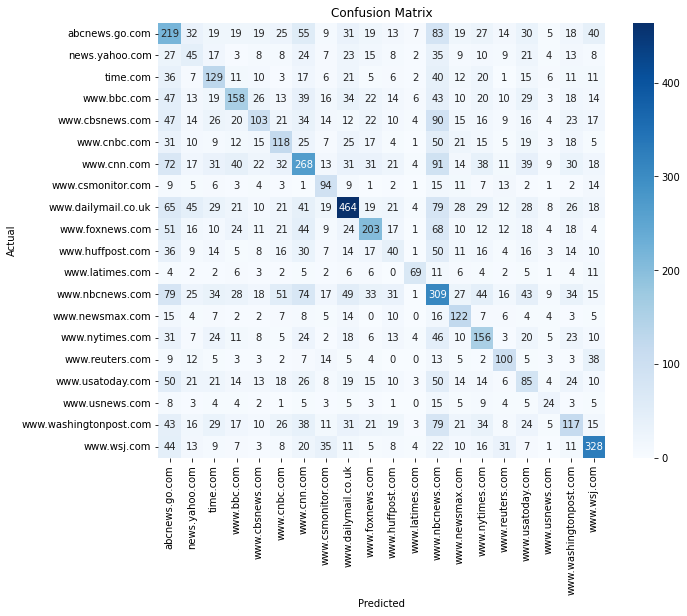

In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
from torchvision import models, transforms
from PIL import Image
import numpy as np
from facenet_pytorch import MTCNN, InceptionResnetV1
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

class MultiHeadAttention(nn.Module):
    def __init__(self, embed_size, heads):
        super(MultiHeadAttention, self).__init__()
        self.embed_size = embed_size
        self.heads = heads
        self.head_dim = embed_size // heads
        assert self.head_dim * heads == embed_size
        self.values = nn.Linear(embed_size, embed_size, bias=False)
        self.keys = nn.Linear(embed_size, embed_size, bias=False)
        self.queries = nn.Linear(embed_size, embed_size, bias=False)
        self.fc_out = nn.Linear(embed_size, embed_size)

    def forward(self, values, keys, query):
        N = query.shape[0]
        value_len, key_len, query_len = values.shape[1], keys.shape[1], query.shape[1]
        values = self.values(values)
        keys = self.keys(keys)
        queries = self.queries(query)
        values = values.reshape(N, value_len, self.heads, self.head_dim)
        keys = keys.reshape(N, key_len, self.heads, self.head_dim)
        queries = queries.reshape(N, query_len, self.heads, self.head_dim)
        energy = torch.einsum("nqhd,nkhd->nhqk", [queries, keys])
        attention = torch.nn.functional.softmax(energy / (self.embed_size ** (1 / 2)), dim=3)
        out = torch.einsum("nhql,nlhd->nqhd", [attention, values]).reshape(
            N, query_len, self.heads * self.head_dim
        )
        out = self.fc_out(out)
        return out

class ImprovedMultiModalModel(nn.Module):
    def __init__(self, num_person_categories, num_party_categories, num_topics, num_classes,
                 num_date_categories, embedding_dim_person=8, embedding_dim_party=2,
                 embedding_dim_date=4, num_attention_heads=8, window_size=32):
        super(ImprovedMultiModalModel, self).__init__()
        self.face_vgg = InceptionResnetV1(pretrained='vggface2').eval()
        for param in list(self.face_vgg.parameters())[:-5]:
            param.requires_grad = False
        self.fc_vgg_1 = nn.Linear(512, 256)
        self.bn_vgg = nn.BatchNorm1d(256)
        self.dropout_vgg = nn.Dropout(0.3)
        self.person_embedding = nn.Embedding(num_person_categories, embedding_dim_person)
        self.party_embedding = nn.Embedding(num_party_categories, embedding_dim_party)
        self.date_embedding = nn.Embedding(num_date_categories, embedding_dim_date)
        self.fc_structured_proj = nn.Linear(
            embedding_dim_person + embedding_dim_party + num_topics + embedding_dim_date, 64
        )
        self.structured_attention = MultiHeadAttention(embed_size=64, heads=num_attention_heads)
        self.bn_structured = nn.BatchNorm1d(64)
        self.dropout_structured = nn.Dropout(0.4)
        self.fc_person_party_proj = nn.Linear(
            embedding_dim_person + embedding_dim_party, window_size
        )
        self.chunked_attention = MultiHeadAttention(embed_size=window_size, heads=num_attention_heads)
        resnet_pretrained = models.resnet101(pretrained=True)
        for param in list(resnet_pretrained.parameters())[:-10]:
            param.requires_grad = False
        self.features_resnet = nn.Sequential(*list(resnet_pretrained.children())[:-1])
        self.fc_resnet = nn.Linear(resnet_pretrained.fc.in_features, 512)
        self.bn_resnet = nn.BatchNorm1d(512)
        self.dropout_resnet = nn.Dropout(0.6)
        self.fc_out = nn.Linear(256 + 64 + 512, num_classes)
        self.dropout_out = nn.Dropout(0.5)

    def forward(self, resnet_img, face_img, person, party, topic_distribution, date):
        vgg_features = self.face_vgg(face_img)
        vgg_features = F.relu(self.bn_vgg(self.fc_vgg_1(vgg_features)))
        vgg_features = self.dropout_vgg(vgg_features)
        person_embedded = self.person_embedding(person)
        party_embedded = self.party_embedding(party)
        date_embedded = self.date_embedding(date)
        structured_data = torch.cat(
            (person_embedded, party_embedded, topic_distribution, date_embedded), dim=1
        )
        structured_data_proj = F.relu(self.fc_structured_proj(structured_data))
        structured_data = self.structured_attention(
            structured_data_proj.unsqueeze(1),
            structured_data_proj.unsqueeze(1),
            structured_data_proj.unsqueeze(1)
        ).squeeze(1)
        structured_data = F.relu(self.bn_structured(structured_data))
        structured_data = self.dropout_structured(structured_data)
        person_party_data = torch.cat((person_embedded, party_embedded), dim=1)
        person_party_proj = self.fc_person_party_proj(person_party_data).unsqueeze(1)
        vgg_chunks = vgg_features.view(vgg_features.size(0), 8, -1)
        attended_chunks = []
        for i in range(8):
            vgg_chunk = vgg_chunks[:, i, :].unsqueeze(1)
            attention_out = self.chunked_attention(
                person_party_proj, vgg_chunk, vgg_chunk
            ).squeeze(1)
            attended_chunks.append(attention_out)
        attended_vgg_features = torch.cat(attended_chunks, dim=1)
        resnet_features = self.features_resnet(resnet_img)
        resnet_features = torch.flatten(resnet_features, 1)
        resnet_features = F.relu(self.bn_resnet(self.fc_resnet(resnet_features)))
        resnet_features = self.dropout_resnet(resnet_features)
        combined_features = torch.cat(
            (attended_vgg_features, structured_data, resnet_features), dim=1
        )
        combined_features = self.dropout_out(combined_features)
        out = self.fc_out(combined_features)
        return out

class EvalDataset(Dataset):
    def __init__(self, dataframe, image_dir='./images_Polarization', transform=None, face_transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
        self.face_transform = face_transform
        self.person_encoder = LabelEncoder()
        self.outlet_encoder = LabelEncoder()
        self.party_encoder = LabelEncoder()
        self.date_encoder = LabelEncoder()
        self.person_encoder.fit(dataframe['Top1_Person'])
        self.outlet_encoder.fit(dataframe['News Center'])
        self.party_encoder.fit(dataframe['Real Person Side'])
        self.date_encoder.fit(dataframe['YearMonth'])
        self.person_encoded = self.person_encoder.transform(dataframe['Top1_Person'])
        self.outlet_encoded = self.outlet_encoder.transform(dataframe['News Center'])
        self.party_encoded = self.party_encoder.transform(dataframe['Real Person Side'])
        self.dates = self.date_encoder.transform(dataframe['YearMonth'])
        self.topic_columns = [col for col in dataframe.columns if col.startswith('topic_')]
        self.mtcnn = MTCNN(
            keep_all=False,
            device=torch.device('cpu'),
            thresholds=[0.4, 0.5, 0.6],
            min_face_size=15,
            factor=0.6
        )

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_id = self.dataframe.iloc[idx]['ID']
        img_path = os.path.join(self.image_dir, f"{img_id}.jpg")
        try:
            img = Image.open(img_path).convert('RGB')
        except Exception:
            img = Image.new('RGB', (224, 224), (0, 0, 0))
        face_img = self.mtcnn(img)
        if face_img is None:
            face_img = transforms.Resize((224, 224))(img)
            face_img = transforms.ToTensor()(face_img)
        else:
            face_img = transforms.Resize((224, 224))(face_img)
        if self.transform:
            resnet_img = self.transform(img)
        else:
            resnet_img = transforms.Resize((224, 224))(img)
            resnet_img = transforms.ToTensor()(resnet_img)
        if self.face_transform:
            if isinstance(face_img, torch.Tensor):
                face_img = transforms.ToPILImage()(face_img)
            face_img = self.face_transform(face_img)
        label = torch.tensor(self.outlet_encoded[idx], dtype=torch.long)
        person = torch.tensor(self.person_encoded[idx], dtype=torch.long)
        party = torch.tensor(self.party_encoded[idx], dtype=torch.long)
        date = torch.tensor(self.dates[idx], dtype=torch.long)
        topic_distribution = self.dataframe.iloc[idx][self.topic_columns].values.astype(np.float32)
        topic_distribution = torch.tensor(topic_distribution)
        return resnet_img, face_img, label, person, party, topic_distribution, date

df = pd.read_pickle('cleaned_complete_data_Face_Verification_Info_Raady_MLModel_Date.pkl')
df["YearMonth"] = pd.to_datetime(df["Date_Pub"], errors="coerce").dt.to_period("M").astype(str)
checkpoint_path = f'model/ML_Model_1.pth'


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

face_transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
])

full_dataset = EvalDataset(df, transform=transform, face_transform=face_transform)
full_loader = DataLoader(full_dataset, batch_size=64, shuffle=False, num_workers=30)

num_person_categories = df['Top1_Person'].nunique()
num_party_categories = df['Real Person Side'].nunique()
num_classes = df['News Center'].nunique()
num_date_categories = df['YearMonth'].nunique()
num_topics = len([col for col in df.columns if col.startswith('topic_')])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = ImprovedMultiModalModel(
    num_person_categories=num_person_categories,
    num_party_categories=num_party_categories,
    num_topics=num_topics,
    num_classes=num_classes,
    num_date_categories=num_date_categories,
    embedding_dim_person=8,
    embedding_dim_party=2,
    embedding_dim_date=4,
    num_attention_heads=8
).to(device)

checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

def get_predictions_and_probs(model, dataloader, device):
    all_predictions, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for img, face_img, label, person, party, topic_distribution, date in tqdm(dataloader):
            img = img.to(device)
            face_img = face_img.to(device)
            person = person.to(device)
            party = party.to(device)
            topic_distribution = topic_distribution.to(device)
            date = date.to(device)
            label = label.to(device)
            outputs = model(img, face_img, person, party, topic_distribution, date)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            all_predictions.extend(preds.cpu().numpy())
            all_labels.extend(label.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return all_predictions, all_labels, all_probs

predictions, labels, probs = get_predictions_and_probs(model, full_loader, device)

label_encoder = full_dataset.outlet_encoder
decoded_predictions = label_encoder.inverse_transform(predictions)
df['Model_Prediction'] = decoded_predictions
df['Correct_Prediction'] = (df['Model_Prediction'] == df['News Center']).map({True: 'Yes', False: 'No'})

prob_column_names = [f'prob_{class_name}' for class_name in label_encoder.classes_]
prob_df = pd.DataFrame(probs, columns=prob_column_names)
df.reset_index(drop=True, inplace=True)
df = pd.concat([df, prob_df], axis=1)

subset_filter = 'val'
if 'dataset_type' in df.columns:
    subset_df = df[df['dataset_type'] == subset_filter]
    if len(subset_df) == 0:
        subset_df = df
else:
    subset_df = df

y_true = subset_df['News Center'].values
y_pred = subset_df['Model_Prediction'].values

print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_true, y_pred, labels=label_encoder.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Model 1: CVS Validation
Corresponds to the results reported in Web Appendix E.3.

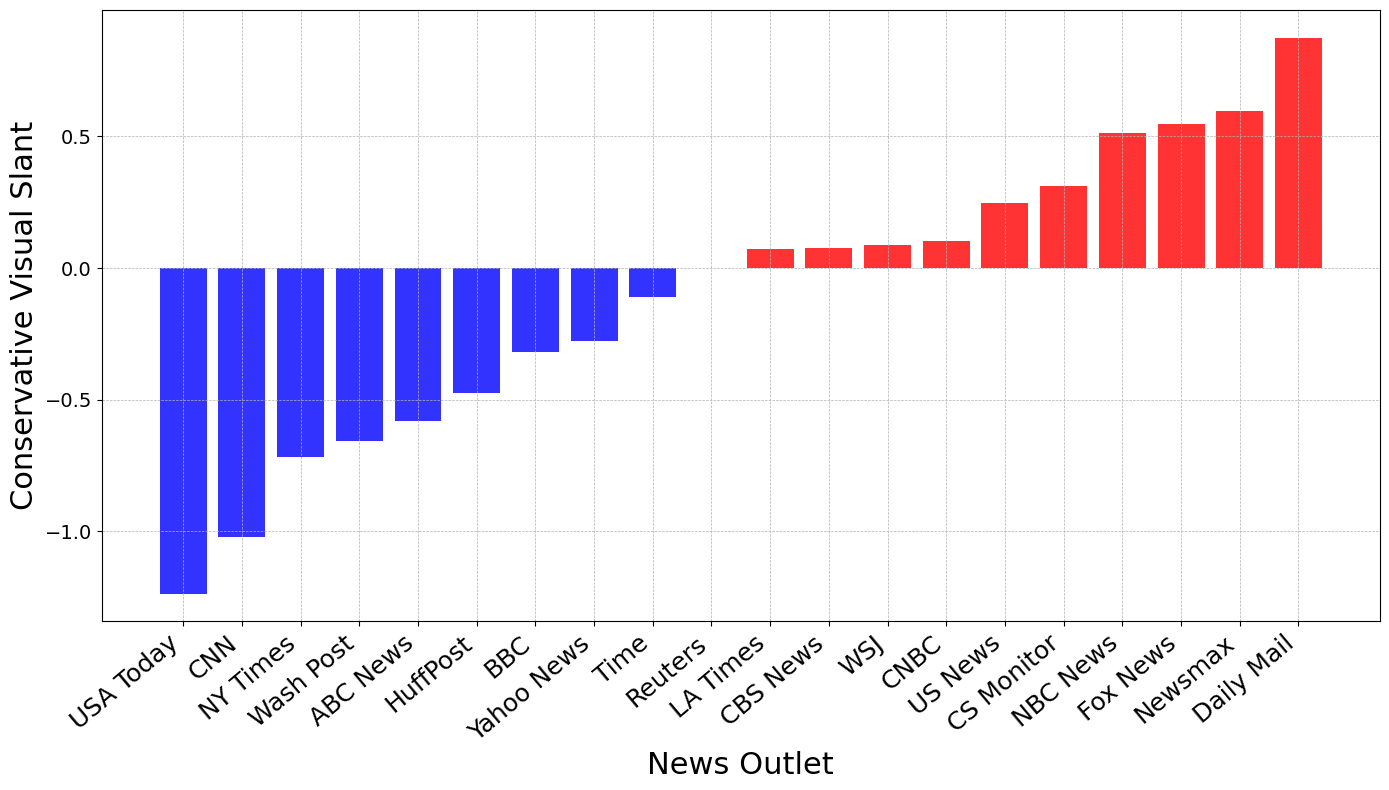

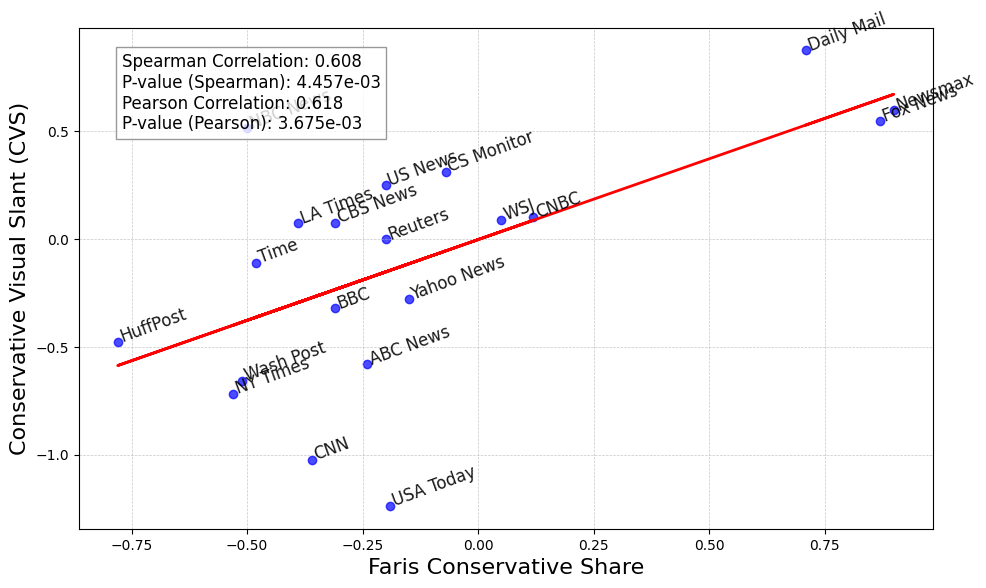

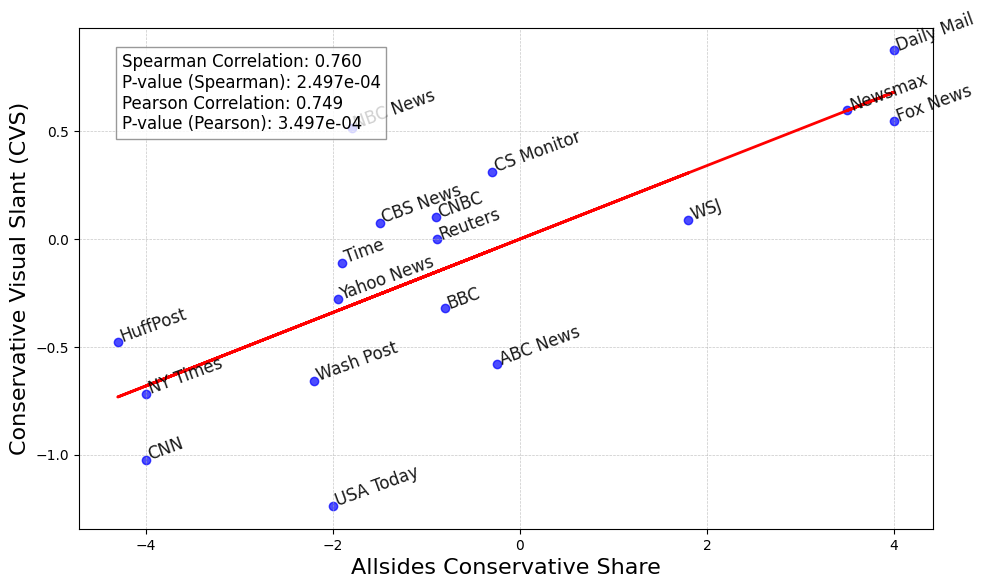

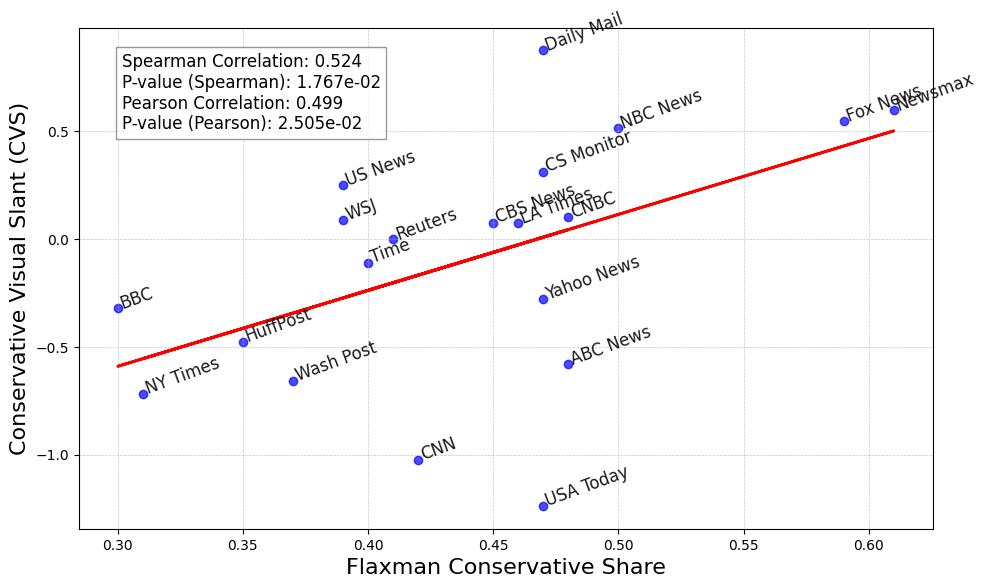

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
import statsmodels.api as sm
from scipy.stats import spearmanr, pearsonr

df = pd.read_csv('Final_CSV_For_Analysis_Model_1.csv').copy()

plt.style.use('default')

news_center_affiliations = {
    'www.bbc.com': 'Democratic', 'www.nytimes.com': 'Democratic', 'www.huffpost.com': 'Democratic',
    'www.washingtonpost.com': 'Democratic', 'www.wsj.com': 'Republican', 'www.cnn.com': 'Democratic',
    'www.cbsnews.com': 'Democratic', 'www.latimes.com': 'Neutral', 'www.dailymail.co.uk': 'Republican',
    'abcnews.go.com': 'Democratic', 'www.nbcnews.com': 'Democratic', 'www.foxnews.com': 'Republican',
    'www.newsmax.com': 'Republican', 'www.usnews.com': 'Neutral', 'time.com': 'Democratic',
    'www.reuters.com': 'Neutral', 'news.yahoo.com': 'Neutral', 'www.usatoday.com': 'Neutral',
    'www.cnbc.com': 'Democratic', 'www.csmonitor.com': 'Neutral'
}

short_names = {
    'www.bbc.com': 'BBC', 'www.nytimes.com': 'NY Times', 'www.huffpost.com': 'HuffPost',
    'www.washingtonpost.com': 'Wash Post', 'www.wsj.com': 'WSJ', 'www.cnn.com': 'CNN',
    'www.cbsnews.com': 'CBS News', 'www.latimes.com': 'LA Times', 'www.dailymail.co.uk': 'Daily Mail',
    'abcnews.go.com': 'ABC News', 'www.nbcnews.com': 'NBC News', 'www.foxnews.com': 'Fox News',
    'www.newsmax.com': 'Newsmax', 'www.usnews.com': 'US News', 'time.com': 'Time',
    'www.reuters.com': 'Reuters', 'news.yahoo.com': 'Yahoo News', 'www.usatoday.com': 'USA Today',
    'www.cnbc.com': 'CNBC', 'www.csmonitor.com': 'CS Monitor'
}

selected_news_centers = list(news_center_affiliations.keys())

mean_smile_effect = {
    'News Center': [],
    'Republican Politicians': [],
    'Democratic Politicians': []
}

for news_center in selected_news_centers:
    smile_column = f"Final_Ratio_{news_center}"
    if smile_column in df.columns:
        republican_mean_effect = df[(df['Real Person Side'] == 'Republican')][smile_column].mean()
        democratic_mean_effect = df[(df['Real Person Side'] == 'Democratic')][smile_column].mean()
        mean_smile_effect['News Center'].append(news_center)
        mean_smile_effect['Republican Politicians'].append(republican_mean_effect if not np.isnan(republican_mean_effect) else 0)
        mean_smile_effect['Democratic Politicians'].append(democratic_mean_effect if not np.isnan(democratic_mean_effect) else 0)

mean_smile_effect_df = pd.DataFrame(mean_smile_effect)
mean_smile_effect_df['Overall Polarization'] = (
    mean_smile_effect_df['Republican Politicians']
    - mean_smile_effect_df['Democratic Politicians']
)
mean_smile_effect_df = mean_smile_effect_df.sort_values(by='Overall Polarization', ascending=True)

fig3, ax3 = plt.subplots(figsize=(14, 8))
bar_colors = ['red' if value > 0 else 'blue' for value in mean_smile_effect_df['Overall Polarization']]
ax3.bar(mean_smile_effect_df['News Center'], mean_smile_effect_df['Overall Polarization'],
        color=bar_colors, alpha=0.8)
ax3.set_xlabel('News Outlet', fontsize=22)
ax3.set_ylabel('Conservative Visual Slant', fontsize=22)
ax3.set_xticks(range(len(mean_smile_effect_df['News Center'])))
ax3.set_xticklabels([short_names[nc] for nc in mean_smile_effect_df['News Center']],
                     ha='right', rotation=40, fontsize=18)
ax3.tick_params(axis='y', labelsize=14)
ax3.grid(True, which='both', linestyle='--', linewidth=0.5)
fig3.tight_layout()
fig3.savefig('Fig_overall_polarization.png', dpi=70)
plt.show()

harvard = {
    'www.bbc.com': -0.31, 'www.nytimes.com': -0.53, 'www.huffpost.com': -0.78,
    'www.washingtonpost.com': -0.51, 'www.wsj.com': 0.05, 'www.usnews.com': -0.20,
    'time.com': -0.48, 'www.reuters.com': -0.20, 'www.cnn.com': -0.36,
    'www.cbsnews.com': -0.31, 'www.latimes.com': -0.39, 'news.yahoo.com': -0.15,
    'www.usatoday.com': -0.19, 'www.dailymail.co.uk': 0.71, 'www.cnbc.com': 0.12,
    'www.csmonitor.com': -0.07, 'abcnews.go.com': -0.24, 'www.nbcnews.com': -0.50,
    'www.foxnews.com': 0.87, 'www.newsmax.com': 0.9
}

allsides = {
    'www.bbc.com': -0.8, 'www.nytimes.com': -4, 'www.huffpost.com': -4.3,
    'www.washingtonpost.com': -2.2, 'www.wsj.com': 1.8, 'time.com': -1.9,
    'www.reuters.com': -0.89, 'www.cnn.com': -4, 'www.cbsnews.com': -1.5,
    'news.yahoo.com': -1.95, 'www.usatoday.com': -2,
    'www.dailymail.co.uk': 4, 'www.cnbc.com': -0.9,
    'www.csmonitor.com': -0.3, 'abcnews.go.com': -0.24,
    'www.nbcnews.com': -1.8, 'www.foxnews.com': 4,
    'www.newsmax.com': 3.5
}

other_paper = {
    'www.bbc.com': 0.30, 'www.nytimes.com': 0.31, 'www.huffpost.com': 0.35,
    'www.washingtonpost.com': 0.37, 'www.wsj.com': 0.39, 'www.usnews.com': 0.39,
    'time.com': 0.40, 'www.reuters.com': 0.41, 'www.cnn.com': 0.42,
    'www.cbsnews.com': 0.45, 'www.latimes.com': 0.46,
    'news.yahoo.com': 0.47, 'www.usatoday.com': 0.47,
    'www.dailymail.co.uk': 0.47, 'www.cnbc.com': 0.48,
    'www.csmonitor.com': 0.47, 'abcnews.go.com': 0.48,
    'www.nbcnews.com': 0.50, 'www.foxnews.com': 0.59,
    'www.newsmax.com': 0.61
}

def plot_and_save_regression_with_correlation(conservative_share, conservative_label, filename):
    valid_outlets = [nc for nc in mean_smile_effect_df['News Center'] if nc in conservative_share]
    x = [conservative_share[nc] for nc in valid_outlets]
    y = mean_smile_effect_df.loc[
        mean_smile_effect_df['News Center'].isin(valid_outlets),
        'Overall Polarization'
    ]
    spearman_corr, spearman_p_value = spearmanr(x, y)
    pearson_corr, pearson_p_value = pearsonr(x, y)
    x_with_constant = sm.add_constant(x)
    model = sm.OLS(y, x_with_constant).fit()
    intercept = model.params.iloc[0]
    slope = model.params.iloc[1]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(x, y, color='blue', alpha=0.7)
    ax.plot(x, intercept + slope * np.array(x),
            color='red', linestyle='-', linewidth=2)
    valid_short_names = [short_names[nc] for nc in valid_outlets]
    for i, short_name in enumerate(valid_short_names):
        ax.annotate(short_name, (x[i], y.iloc[i]),
                    fontsize=12, alpha=0.9, rotation=20)
    stats_text = (
        f"Spearman Correlation: {spearman_corr:.3f}\n"
        f"P-value (Spearman): {spearman_p_value:.3e}\n"
        f"Pearson Correlation: {pearson_corr:.3f}\n"
        f"P-value (Pearson): {pearson_p_value:.3e}"
    )
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
            fontsize=12, verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
    ax.set_xlabel(conservative_label, fontsize=16)
    ax.set_ylabel("Conservative Visual Slant (CVS)", fontsize=16)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.savefig(filename, dpi=100)
    plt.show()
    plt.close(fig)

plot_and_save_regression_with_correlation(
    harvard,
    "Faris Conservative Share",
    "Harvard_Correlation_vs_Polarization.png"
)

plot_and_save_regression_with_correlation(
    allsides,
    "Allsides Conservative Share",
    "Allsides_Correlation_vs_Polarization.png"
)

plot_and_save_regression_with_correlation(
    other_paper,
    "Flaxman Conservative Share",
    "OtherPaper_Correlation_vs_Polarization.png"
)

## Model 2: ML Performance
Corresponds to the results reported in Web Appendix E.3.

/home/jupyter-hoc_project/.local/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/jupyter-hoc_project/.local/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading checkpoint from model_checkpoint_MultiClasses_With_Date_6_train2/epoch_11.pth
Checkpoint loaded successfully!


Evaluating: 100%|██████████| 985/985 [04:26<00:00,  3.70it/s]



=== CLASSIFICATION REPORT (VAL set) ===
                        precision    recall  f1-score   support

        abcnews.go.com       0.28      0.16      0.20       703
        news.yahoo.com       0.14      0.11      0.13       296
              time.com       0.20      0.31      0.24       369
           www.bbc.com       0.35      0.26      0.30       554
       www.cbsnews.com       0.18      0.24      0.21       517
          www.cnbc.com       0.26      0.28      0.27       410
           www.cnn.com       0.29      0.22      0.25       832
     www.csmonitor.com       0.25      0.39      0.30       203
   www.dailymail.co.uk       0.60      0.46      0.52       987
       www.foxnews.com       0.31      0.37      0.34       577
      www.huffpost.com       0.15      0.15      0.15       321
       www.latimes.com       0.39      0.52      0.44       151
       www.nbcnews.com       0.25      0.08      0.12       937
       www.newsmax.com       0.38      0.45      0.41       24

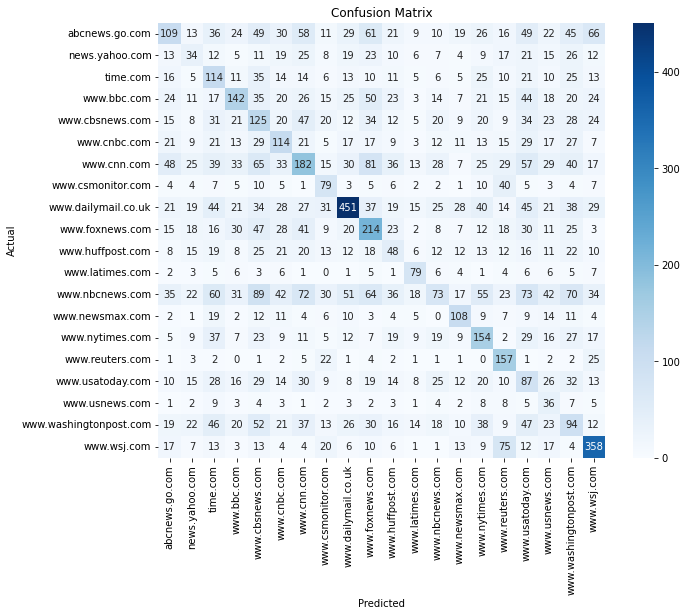

In [2]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
from torchvision import models, transforms
from PIL import Image
import numpy as np
from facenet_pytorch import MTCNN, InceptionResnetV1
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

class MultiHeadAttention(nn.Module):
    def __init__(self, embed_size, heads):
        super(MultiHeadAttention, self).__init__()
        self.embed_size = embed_size
        self.heads = heads
        self.head_dim = embed_size // heads
        assert self.head_dim * heads == embed_size
        self.values = nn.Linear(embed_size, embed_size, bias=False)
        self.keys = nn.Linear(embed_size, embed_size, bias=False)
        self.queries = nn.Linear(embed_size, embed_size, bias=False)
        self.fc_out = nn.Linear(embed_size, embed_size)

    def forward(self, values, keys, query):
        N = query.shape[0]
        value_len, key_len, query_len = values.shape[1], keys.shape[1], query.shape[1]
        values = self.values(values)
        keys = self.keys(keys)
        queries = self.queries(query)
        values = values.reshape(N, value_len, self.heads, self.head_dim)
        keys = keys.reshape(N, key_len, self.heads, self.head_dim)
        queries = queries.reshape(N, query_len, self.heads, self.head_dim)
        energy = torch.einsum("nqhd,nkhd->nhqk", [queries, keys])
        attention = torch.nn.functional.softmax(energy / (self.embed_size ** (1 / 2)), dim=3)
        out = torch.einsum("nhql,nlhd->nqhd", [attention, values]).reshape(
            N, query_len, self.heads * self.head_dim
        )
        out = self.fc_out(out)
        return out

class ImprovedMultiModalModel(nn.Module):
    def __init__(self, num_person_categories, num_party_categories, num_topics, num_classes,
                 num_date_categories, embedding_dim_person=8, embedding_dim_party=2,
                 embedding_dim_date=4, num_attention_heads=8, window_size=32):
        super(ImprovedMultiModalModel, self).__init__()
        self.face_vgg = InceptionResnetV1(pretrained='vggface2').eval()
        for param in list(self.face_vgg.parameters())[:-5]:
            param.requires_grad = False
        self.fc_vgg_1 = nn.Linear(512, 256)
        self.bn_vgg = nn.BatchNorm1d(256)
        self.dropout_vgg = nn.Dropout(0.3)
        self.person_embedding = nn.Embedding(num_person_categories, embedding_dim_person)
        self.party_embedding = nn.Embedding(num_party_categories, embedding_dim_party)
        self.date_embedding = nn.Embedding(num_date_categories, embedding_dim_date)
        self.fc_structured_proj = nn.Linear(
            embedding_dim_person + embedding_dim_party + num_topics + embedding_dim_date, 64
        )
        self.structured_attention = MultiHeadAttention(embed_size=64, heads=num_attention_heads)
        self.bn_structured = nn.BatchNorm1d(64)
        self.dropout_structured = nn.Dropout(0.4)
        self.fc_person_party_proj = nn.Linear(
            embedding_dim_person + embedding_dim_party, window_size
        )
        self.chunked_attention = MultiHeadAttention(embed_size=window_size, heads=num_attention_heads)
        resnet_pretrained = models.resnet101(pretrained=True)
        for param in list(resnet_pretrained.parameters())[:-10]:
            param.requires_grad = False
        self.features_resnet = nn.Sequential(*list(resnet_pretrained.children())[:-1])
        self.fc_resnet = nn.Linear(resnet_pretrained.fc.in_features, 512)
        self.bn_resnet = nn.BatchNorm1d(512)
        self.dropout_resnet = nn.Dropout(0.6)
        self.fc_out = nn.Linear(256 + 64 + 512, num_classes)
        self.dropout_out = nn.Dropout(0.5)

    def forward(self, resnet_img, face_img, person, party, topic_distribution, date):
        vgg_features = self.face_vgg(face_img)
        vgg_features = F.relu(self.bn_vgg(self.fc_vgg_1(vgg_features)))
        vgg_features = self.dropout_vgg(vgg_features)
        person_embedded = self.person_embedding(person)
        party_embedded = self.party_embedding(party)
        date_embedded = self.date_embedding(date)
        structured_data = torch.cat(
            (person_embedded, party_embedded, topic_distribution, date_embedded), dim=1
        )
        structured_data_proj = F.relu(self.fc_structured_proj(structured_data))
        structured_data = self.structured_attention(
            structured_data_proj.unsqueeze(1),
            structured_data_proj.unsqueeze(1),
            structured_data_proj.unsqueeze(1)
        ).squeeze(1)
        structured_data = F.relu(self.bn_structured(structured_data))
        structured_data = self.dropout_structured(structured_data)
        person_party_data = torch.cat((person_embedded, party_embedded), dim=1)
        person_party_proj = self.fc_person_party_proj(person_party_data).unsqueeze(1)
        vgg_chunks = vgg_features.view(vgg_features.size(0), 8, -1)
        attended_chunks = []
        for i in range(8):
            vgg_chunk = vgg_chunks[:, i, :].unsqueeze(1)
            attention_out = self.chunked_attention(
                person_party_proj, vgg_chunk, vgg_chunk
            ).squeeze(1)
            attended_chunks.append(attention_out)
        attended_vgg_features = torch.cat(attended_chunks, dim=1)
        resnet_features = self.features_resnet(resnet_img)
        resnet_features = torch.flatten(resnet_features, 1)
        resnet_features = F.relu(self.bn_resnet(self.fc_resnet(resnet_features)))
        resnet_features = self.dropout_resnet(resnet_features)
        combined_features = torch.cat(
            (attended_vgg_features, structured_data, resnet_features), dim=1
        )
        combined_features = self.dropout_out(combined_features)
        out = self.fc_out(combined_features)
        return out

class EvalDataset(Dataset):
    def __init__(self, dataframe, image_dir='data/images_Polarization', transform=None, face_transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
        self.face_transform = face_transform
        self.person_encoder = LabelEncoder()
        self.outlet_encoder = LabelEncoder()
        self.party_encoder = LabelEncoder()
        self.date_encoder = LabelEncoder()
        self.person_encoder.fit(dataframe['Top1_Person'])
        self.outlet_encoder.fit(dataframe['News Center'])
        self.party_encoder.fit(dataframe['Real Person Side'])
        self.date_encoder.fit(dataframe['YearMonth'])
        self.person_encoded = self.person_encoder.transform(dataframe['Top1_Person'])
        self.outlet_encoded = self.outlet_encoder.transform(dataframe['News Center'])
        self.party_encoded = self.party_encoder.transform(dataframe['Real Person Side'])
        self.dates = self.date_encoder.transform(dataframe['YearMonth'])
        self.topic_columns = [col for col in dataframe.columns if col.startswith('topic_')]
        self.mtcnn = MTCNN(
            keep_all=False,
            device=torch.device('cpu'),
            thresholds=[0.4, 0.5, 0.6],
            min_face_size=15,
            factor=0.6
        )

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_id = self.dataframe.iloc[idx]['ID']
        img_path = os.path.join(self.image_dir, f"{img_id}.jpg")
        try:
            img = Image.open(img_path).convert('RGB')
        except Exception:
            img = Image.new('RGB', (224, 224), (0, 0, 0))
        face_img = self.mtcnn(img)
        if face_img is None:
            face_img = transforms.Resize((224, 224))(img)
            face_img = transforms.ToTensor()(face_img)
        else:
            face_img = transforms.Resize((224, 224))(face_img)
        if self.transform:
            resnet_img = self.transform(img)
        else:
            resnet_img = transforms.Resize((224, 224))(img)
            resnet_img = transforms.ToTensor()(resnet_img)
        if self.face_transform:
            if isinstance(face_img, torch.Tensor):
                face_img = transforms.ToPILImage()(face_img)
            face_img = self.face_transform(face_img)
        label = torch.tensor(self.outlet_encoded[idx], dtype=torch.long)
        person = torch.tensor(self.person_encoded[idx], dtype=torch.long)
        party = torch.tensor(self.party_encoded[idx], dtype=torch.long)
        date = torch.tensor(self.dates[idx], dtype=torch.long)
        topic_distribution = self.dataframe.iloc[idx][self.topic_columns].values.astype(np.float32)
        topic_distribution = torch.tensor(topic_distribution)
        return resnet_img, face_img, label, person, party, topic_distribution, date

df = pd.read_pickle('cleaned_complete_data_Face_Verification_Info_Raady_MLModel_Date.pkl')
df["YearMonth"] = pd.to_datetime(df["Date_Pub"], errors="coerce").dt.to_period("M").astype(str)
checkpoint_path = f'model/ML_Model_2.pth'


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

face_transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
])

full_dataset = EvalDataset(df, transform=transform, face_transform=face_transform)
full_loader = DataLoader(full_dataset, batch_size=64, shuffle=False, num_workers=30)

num_person_categories = df['Top1_Person'].nunique()
num_party_categories = df['Real Person Side'].nunique()
num_classes = df['News Center'].nunique()
num_date_categories = df['YearMonth'].nunique()
num_topics = len([col for col in df.columns if col.startswith('topic_')])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = ImprovedMultiModalModel(
    num_person_categories=num_person_categories,
    num_party_categories=num_party_categories,
    num_topics=num_topics,
    num_classes=num_classes,
    num_date_categories=num_date_categories,
    embedding_dim_person=8,
    embedding_dim_party=2,
    embedding_dim_date=4,
    num_attention_heads=8
).to(device)

checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

def get_predictions_and_probs(model, dataloader, device):
    all_predictions, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for img, face_img, label, person, party, topic_distribution, date in tqdm(dataloader):
            img = img.to(device)
            face_img = face_img.to(device)
            person = person.to(device)
            party = party.to(device)
            topic_distribution = topic_distribution.to(device)
            date = date.to(device)
            label = label.to(device)
            outputs = model(img, face_img, person, party, topic_distribution, date)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            all_predictions.extend(preds.cpu().numpy())
            all_labels.extend(label.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return all_predictions, all_labels, all_probs

predictions, labels, probs = get_predictions_and_probs(model, full_loader, device)

label_encoder = full_dataset.outlet_encoder
decoded_predictions = label_encoder.inverse_transform(predictions)
df['Model_Prediction'] = decoded_predictions
df['Correct_Prediction'] = (df['Model_Prediction'] == df['News Center']).map({True: 'Yes', False: 'No'})

prob_column_names = [f'prob_{class_name}' for class_name in label_encoder.classes_]
prob_df = pd.DataFrame(probs, columns=prob_column_names)
df.reset_index(drop=True, inplace=True)
df = pd.concat([df, prob_df], axis=1)

subset_filter = 'val'
if 'dataset_type' in df.columns:
    subset_df = df[df['dataset_type'] == subset_filter]
    if len(subset_df) == 0:
        subset_df = df
else:
    subset_df = df

y_true = subset_df['News Center'].values
y_pred = subset_df['Model_Prediction'].values

print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_true, y_pred, labels=label_encoder.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Model 2: CVS Validation
Corresponds to the results reported in Web Appendix E.3.

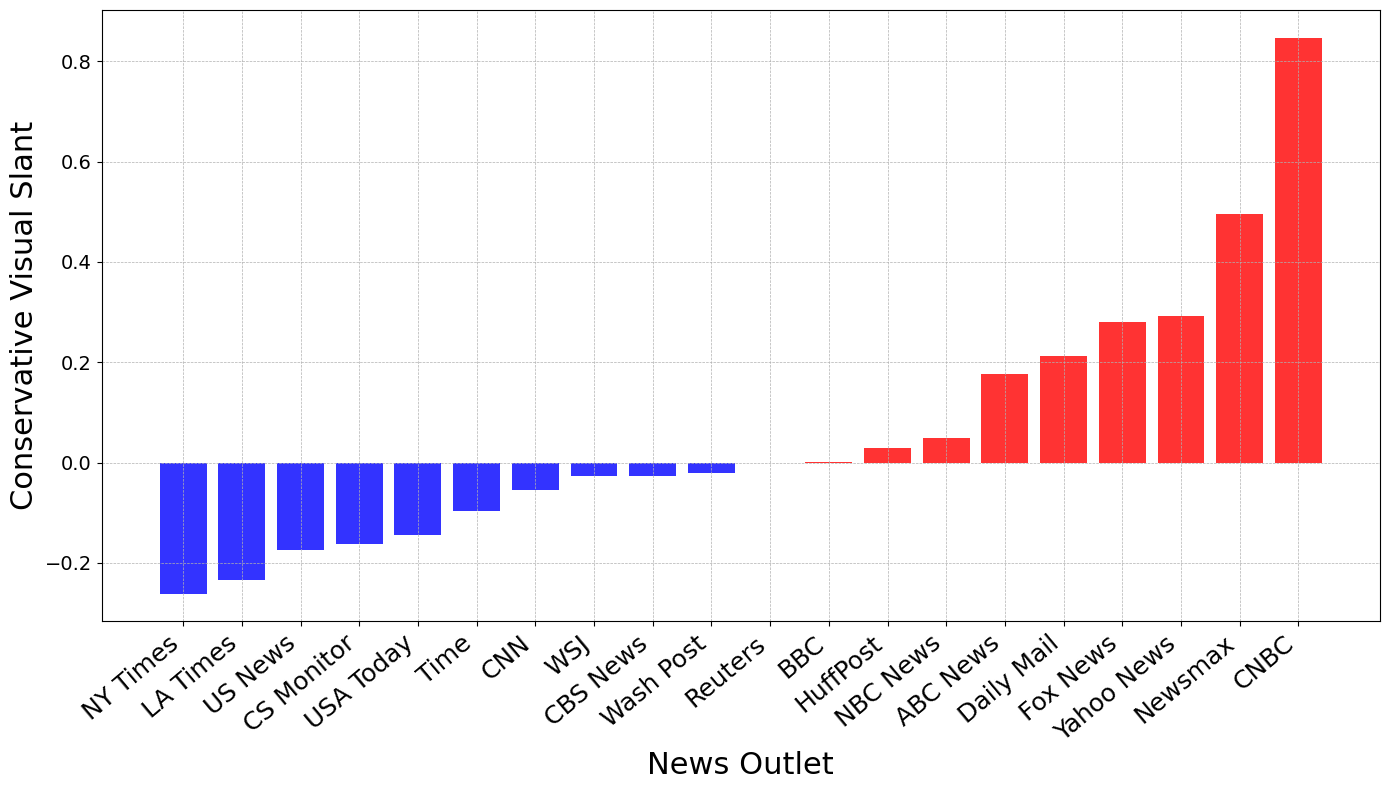

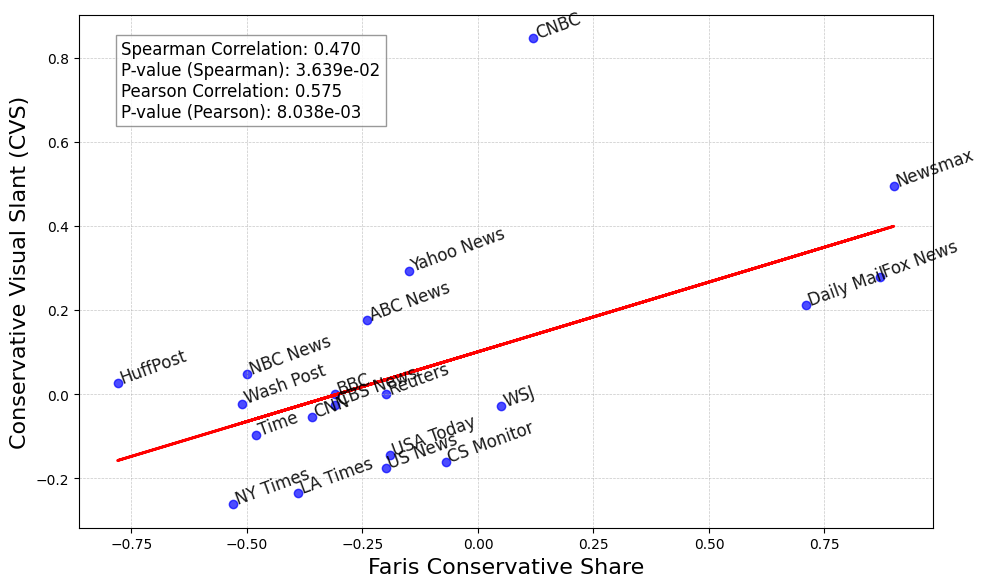

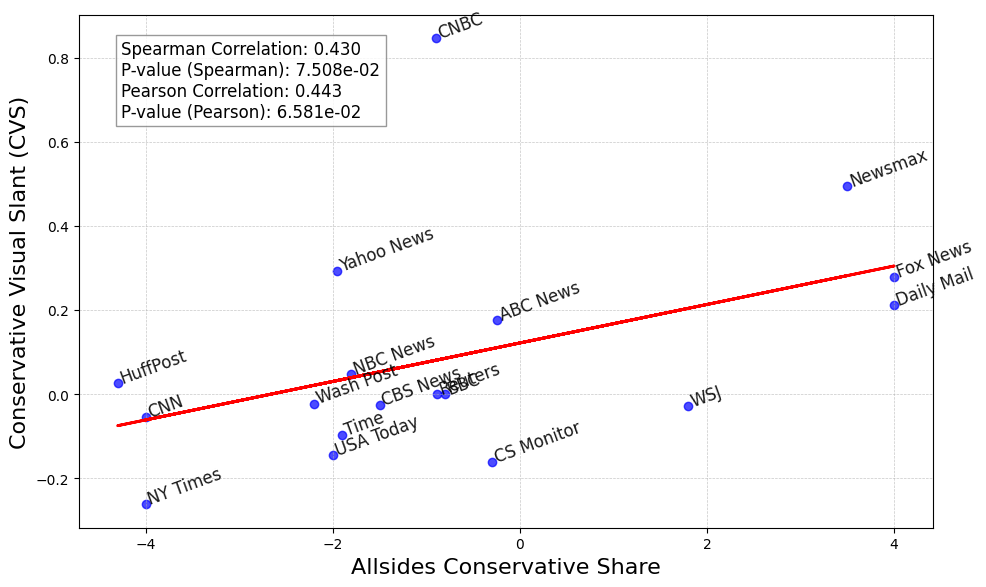

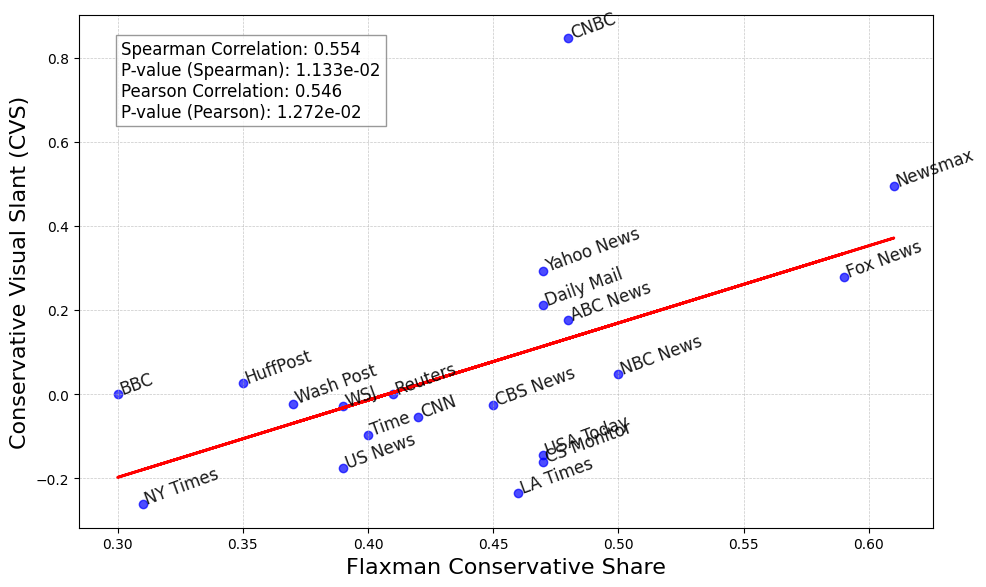

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
import statsmodels.api as sm
from scipy.stats import spearmanr, pearsonr

df = pd.read_csv('Final_CSV_For_Analysis_Model_2.csv').copy()

plt.style.use('default')

news_center_affiliations = {
    'www.bbc.com': 'Democratic', 'www.nytimes.com': 'Democratic', 'www.huffpost.com': 'Democratic',
    'www.washingtonpost.com': 'Democratic', 'www.wsj.com': 'Republican', 'www.cnn.com': 'Democratic',
    'www.cbsnews.com': 'Democratic', 'www.latimes.com': 'Neutral', 'www.dailymail.co.uk': 'Republican',
    'abcnews.go.com': 'Democratic', 'www.nbcnews.com': 'Democratic', 'www.foxnews.com': 'Republican',
    'www.newsmax.com': 'Republican', 'www.usnews.com': 'Neutral', 'time.com': 'Democratic',
    'www.reuters.com': 'Neutral', 'news.yahoo.com': 'Neutral', 'www.usatoday.com': 'Neutral',
    'www.cnbc.com': 'Democratic', 'www.csmonitor.com': 'Neutral'
}

short_names = {
    'www.bbc.com': 'BBC', 'www.nytimes.com': 'NY Times', 'www.huffpost.com': 'HuffPost',
    'www.washingtonpost.com': 'Wash Post', 'www.wsj.com': 'WSJ', 'www.cnn.com': 'CNN',
    'www.cbsnews.com': 'CBS News', 'www.latimes.com': 'LA Times', 'www.dailymail.co.uk': 'Daily Mail',
    'abcnews.go.com': 'ABC News', 'www.nbcnews.com': 'NBC News', 'www.foxnews.com': 'Fox News',
    'www.newsmax.com': 'Newsmax', 'www.usnews.com': 'US News', 'time.com': 'Time',
    'www.reuters.com': 'Reuters', 'news.yahoo.com': 'Yahoo News', 'www.usatoday.com': 'USA Today',
    'www.cnbc.com': 'CNBC', 'www.csmonitor.com': 'CS Monitor'
}

selected_news_centers = list(news_center_affiliations.keys())

mean_smile_effect = {
    'News Center': [],
    'Republican Politicians': [],
    'Democratic Politicians': []
}

for news_center in selected_news_centers:
    smile_column = f"Final_Ratio_{news_center}"
    if smile_column in df.columns:
        republican_mean_effect = df[(df['Real Person Side'] == 'Republican')][smile_column].mean()
        democratic_mean_effect = df[(df['Real Person Side'] == 'Democratic')][smile_column].mean()
        mean_smile_effect['News Center'].append(news_center)
        mean_smile_effect['Republican Politicians'].append(republican_mean_effect if not np.isnan(republican_mean_effect) else 0)
        mean_smile_effect['Democratic Politicians'].append(democratic_mean_effect if not np.isnan(democratic_mean_effect) else 0)

mean_smile_effect_df = pd.DataFrame(mean_smile_effect)
mean_smile_effect_df['Overall Polarization'] = (
    mean_smile_effect_df['Republican Politicians']
    - mean_smile_effect_df['Democratic Politicians']
)
mean_smile_effect_df = mean_smile_effect_df.sort_values(by='Overall Polarization', ascending=True)

fig3, ax3 = plt.subplots(figsize=(14, 8))
bar_colors = ['red' if value > 0 else 'blue' for value in mean_smile_effect_df['Overall Polarization']]
ax3.bar(mean_smile_effect_df['News Center'], mean_smile_effect_df['Overall Polarization'],
        color=bar_colors, alpha=0.8)
ax3.set_xlabel('News Outlet', fontsize=22)
ax3.set_ylabel('Conservative Visual Slant', fontsize=22)
ax3.set_xticks(range(len(mean_smile_effect_df['News Center'])))
ax3.set_xticklabels([short_names[nc] for nc in mean_smile_effect_df['News Center']],
                     ha='right', rotation=40, fontsize=18)
ax3.tick_params(axis='y', labelsize=14)
ax3.grid(True, which='both', linestyle='--', linewidth=0.5)
fig3.tight_layout()
fig3.savefig('Fig_overall_polarization.png', dpi=70)
plt.show()

harvard = {
    'www.bbc.com': -0.31, 'www.nytimes.com': -0.53, 'www.huffpost.com': -0.78,
    'www.washingtonpost.com': -0.51, 'www.wsj.com': 0.05, 'www.usnews.com': -0.20,
    'time.com': -0.48, 'www.reuters.com': -0.20, 'www.cnn.com': -0.36,
    'www.cbsnews.com': -0.31, 'www.latimes.com': -0.39, 'news.yahoo.com': -0.15,
    'www.usatoday.com': -0.19, 'www.dailymail.co.uk': 0.71, 'www.cnbc.com': 0.12,
    'www.csmonitor.com': -0.07, 'abcnews.go.com': -0.24, 'www.nbcnews.com': -0.50,
    'www.foxnews.com': 0.87, 'www.newsmax.com': 0.9
}

allsides = {
    'www.bbc.com': -0.8, 'www.nytimes.com': -4, 'www.huffpost.com': -4.3,
    'www.washingtonpost.com': -2.2, 'www.wsj.com': 1.8, 'time.com': -1.9,
    'www.reuters.com': -0.89, 'www.cnn.com': -4, 'www.cbsnews.com': -1.5,
    'news.yahoo.com': -1.95, 'www.usatoday.com': -2,
    'www.dailymail.co.uk': 4, 'www.cnbc.com': -0.9,
    'www.csmonitor.com': -0.3, 'abcnews.go.com': -0.24,
    'www.nbcnews.com': -1.8, 'www.foxnews.com': 4,
    'www.newsmax.com': 3.5
}

other_paper = {
    'www.bbc.com': 0.30, 'www.nytimes.com': 0.31, 'www.huffpost.com': 0.35,
    'www.washingtonpost.com': 0.37, 'www.wsj.com': 0.39, 'www.usnews.com': 0.39,
    'time.com': 0.40, 'www.reuters.com': 0.41, 'www.cnn.com': 0.42,
    'www.cbsnews.com': 0.45, 'www.latimes.com': 0.46,
    'news.yahoo.com': 0.47, 'www.usatoday.com': 0.47,
    'www.dailymail.co.uk': 0.47, 'www.cnbc.com': 0.48,
    'www.csmonitor.com': 0.47, 'abcnews.go.com': 0.48,
    'www.nbcnews.com': 0.50, 'www.foxnews.com': 0.59,
    'www.newsmax.com': 0.61
}

def plot_and_save_regression_with_correlation(conservative_share, conservative_label, filename):
    valid_outlets = [nc for nc in mean_smile_effect_df['News Center'] if nc in conservative_share]
    x = [conservative_share[nc] for nc in valid_outlets]
    y = mean_smile_effect_df.loc[
        mean_smile_effect_df['News Center'].isin(valid_outlets),
        'Overall Polarization'
    ]
    spearman_corr, spearman_p_value = spearmanr(x, y)
    pearson_corr, pearson_p_value = pearsonr(x, y)
    x_with_constant = sm.add_constant(x)
    model = sm.OLS(y, x_with_constant).fit()
    intercept = model.params.iloc[0]
    slope = model.params.iloc[1]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(x, y, color='blue', alpha=0.7)
    ax.plot(x, intercept + slope * np.array(x),
            color='red', linestyle='-', linewidth=2)
    valid_short_names = [short_names[nc] for nc in valid_outlets]
    for i, short_name in enumerate(valid_short_names):
        ax.annotate(short_name, (x[i], y.iloc[i]),
                    fontsize=12, alpha=0.9, rotation=20)
    stats_text = (
        f"Spearman Correlation: {spearman_corr:.3f}\n"
        f"P-value (Spearman): {spearman_p_value:.3e}\n"
        f"Pearson Correlation: {pearson_corr:.3f}\n"
        f"P-value (Pearson): {pearson_p_value:.3e}"
    )
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
            fontsize=12, verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
    ax.set_xlabel(conservative_label, fontsize=16)
    ax.set_ylabel("Conservative Visual Slant (CVS)", fontsize=16)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.savefig(filename, dpi=100)
    plt.show()
    plt.close(fig)

plot_and_save_regression_with_correlation(
    harvard,
    "Faris Conservative Share",
    "Harvard_Correlation_vs_Polarization.png"
)

plot_and_save_regression_with_correlation(
    allsides,
    "Allsides Conservative Share",
    "Allsides_Correlation_vs_Polarization.png"
)

plot_and_save_regression_with_correlation(
    other_paper,
    "Flaxman Conservative Share",
    "OtherPaper_Correlation_vs_Polarization.png"
)